# Process Mining Pipeline — Maintenance Event Log

Pipeline 4-step untuk analisis process mining dari data job card pemeliharaan pembangkit listrik.

| Step | Deskripsi |
|------|-----------|
| 1 | Data Ingestion & Preprocessing |
| 2 | AI Annotation Builder |
| 3 | Process Model Discovery + Conformance Checking |
| 4 | Report Generation & Visualisasi |


### Persistent Storage with Google Drive

To ensure your output and environment files persist across Colab sessions, you should mount your Google Drive and store your project files there. The default `/content/` directory in Colab is temporary and its contents are deleted when the runtime disconnects.

In [ ]:
from google.colab import drive
from pathlib import Path
import os
import yaml

# Mount Google Drive
drive.mount("/content/drive")

# Base project directory di Google Drive
BASE = Path("/content/drive/MyDrive/pm_project")

# Struktur folder utama
PATHS = {
    "base": BASE,
    "data_dir": BASE / "data",
    "raw_dir": BASE / "data" / "raw",
    "processed_dir": BASE / "data" / "processed",
    "reports_dir": BASE / "reports",
    "config_yaml": BASE / "config.yaml",
}

# Buat semua folder yang dibutuhkan
for directory in [
    PATHS["data_dir"],
    PATHS["raw_dir"],
    PATHS["processed_dir"],
    PATHS["reports_dir"],
]:
    directory.mkdir(parents=True, exist_ok=True)

# Load config jika ada, kalau tidak gunakan default config
if PATHS["config_yaml"].exists():
    with open(PATHS["config_yaml"], "r", encoding="utf-8") as f:
        CONFIG = yaml.safe_load(f) or {}
else:
    CONFIG = {
        "model_discovery": {
            "noise_threshold": 0.20
        }
    }
    with open(PATHS["config_yaml"], "w", encoding="utf-8") as f:
        yaml.safe_dump(CONFIG, f, sort_keys=False)

NOISE_THRESHOLD = CONFIG.get("model_discovery", {}).get("noise_threshold", 0.20)

# Alias supaya tetap kompatibel dengan kode lama
BASE_DIR = str(BASE)
DATA_DIR = str(PATHS["data_dir"])
RAW_DIR = str(PATHS["raw_dir"])
PROCESSED_DIR = str(PATHS["processed_dir"])
REPORT_DIR = str(PATHS["reports_dir"])

print(f"New BASE: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"REPORT_DIR: {REPORT_DIR}")
print(f"Noise threshold: {NOISE_THRESHOLD}")

Mounted at /content/drive
New BASE: /content/drive/MyDrive/pm_project
DATA_DIR: /content/drive/MyDrive/pm_project/data
REPORT_DIR: /content/drive/MyDrive/pm_project/reports
Noise threshold: 0.2


In [ ]:
import os, sys, re, csv, json, time, warnings
from datetime import datetime, timedelta, date
from typing import Optional, Dict, List, Any

warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run([
        "pip","install",
        "pm4py","pandas","numpy","matplotlib",
        "pyyaml","python-dotenv","google-genai",
        "networkx","-q"
    ])


    from google.colab import drive
    drive.mount("/content/drive")

    BASE = "/content/drive/MyDrive/pm_project"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

from dotenv import load_dotenv
load_dotenv(os.path.join(BASE, ".env"))

import pm4py

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

# All file paths in one place — change BASE above to relocate everything
PATHS = {
    "config_yaml":  os.path.join(BASE, "config.yaml"),
    "raw_csv":      os.path.join(BASE, "data/raw/event_log-time.csv"),
    "log_raw":      os.path.join(BASE, "data/processed/log_raw.csv"),
    "log_enr":      os.path.join(BASE, "data/processed/log_enriched.csv"),
    "log_ai":       os.path.join(BASE, "data/processed/log_enriched_ai.csv"),
    "ann_log":      os.path.join(BASE, "data/processed/annotation_log.json"),
    "conf_json":    os.path.join(BASE, "reports/output/conformance_results.json"),
    "out_dir":      os.path.join(BASE, "reports/output"),
    "fig_dir":      os.path.join(BASE, "reports/figures"),
    "reports_dir":  os.path.join(BASE, "reports"),
}

for directory in [
    BASE,
    os.path.join(BASE, "data"),
    os.path.join(BASE, "data/raw"),
    os.path.join(BASE, "data/processed"),
    PATHS["out_dir"],
    PATHS["fig_dir"],
    PATHS["reports_dir"],
]:
    os.makedirs(directory, exist_ok=True)

DEFAULT_CONFIG = {
    "model_discovery": {
        "noise_threshold": 0.20
    },
    "columns": {
        "case_id": "case_id",
        "activity": "activity",
        "timestamp": "timestamp",
        "enriched_activity": "action_type"
    },
    "llm": {
        # Model yang dipakai pada eksperimen GenAI-first.
        "model": "gemini-3.1-flash-lite",
        # Temperature rendah agar semantic annotation stabil/reproducible.
        "temperature": 1,
        "require_ai": True,
        "sleep_between_cases_s": 10.0,
        "max_retries": 3
    }
}


def deep_merge_defaults(config: dict, defaults: dict) -> dict:
    """Merge default keys tanpa menimpa konfigurasi yang sudah ada."""
    config = dict(config or {})
    for key, value in defaults.items():
        if isinstance(value, dict):
            config[key] = deep_merge_defaults(config.get(key, {}), value)
        else:
            config.setdefault(key, value)
    return config


if os.path.exists(PATHS["config_yaml"]):
    with open(PATHS["config_yaml"], "r", encoding="utf-8") as f:
        CONFIG = deep_merge_defaults(yaml.safe_load(f) or {}, DEFAULT_CONFIG)
else:
    CONFIG = DEFAULT_CONFIG
    with open(PATHS["config_yaml"], "w", encoding="utf-8") as f:
        yaml.safe_dump(CONFIG, f, sort_keys=False, allow_unicode=True)

NOISE_THRESHOLD = CONFIG.get("model_discovery", {}).get("noise_threshold", 0.20)

# Backward compatibility alias
P = PATHS

print(f"BASE            : {BASE}")
print(f"Config YAML     : {PATHS['config_yaml']}")
print(f"Raw CSV         : {PATHS['raw_csv']}")
print(f"Output dir      : {PATHS['out_dir']}")
print(f"Figure dir      : {PATHS['fig_dir']}")
print(f"Reports dir     : {PATHS['reports_dir']}")
print(f"Noise threshold : {NOISE_THRESHOLD}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




BASE            : /content/drive/MyDrive/pm_project
Config YAML     : /content/drive/MyDrive/pm_project/config.yaml
Raw CSV         : /content/drive/MyDrive/pm_project/data/raw/event_log-time.csv
Output dir      : /content/drive/MyDrive/pm_project/reports/output
Figure dir      : /content/drive/MyDrive/pm_project/reports/figures
Reports dir     : /content/drive/MyDrive/pm_project/reports
Noise threshold : 0.2


---
## Step 1 — Data Ingestion & Preprocessing

Membaca raw CSV job card, membersihkan, dan menghasilkan dua event log:
- `log_raw.csv` — as-is, hanya cleaning minimal
- `log_enriched.csv` — setelah splitting aktivitas majemuk + abstraksi kategori


In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True)
class ShiftConfig:
    start_hour: int = 8
    start_minute: int = 0
    end_hour: int = 16
    end_minute: int = 30
    hours_per_day: float = 8.5

@dataclass(frozen=True)
class EventDurations:
    safety_induction_min: int = 30
    post_test_min: int = 30
    default_imputed_min: int = 60

SHIFT = ShiftConfig()
DURATIONS = EventDurations()

# Keyword actions yang jika muncul bersamaan → split jadi event terpisah
SPLIT_ORDER = ["PEMBERSIHAN", "PEMERIKSAAN", "PENGUKURAN", "PENGGANTIAN"]

SPLIT_CATEGORY_MAP = {
    "PEMBERSIHAN": "CLEANING",
    "PEMERIKSAAN": "INSPECTION",
    "PENGUKURAN":  "MEASUREMENT",
    "PENGGANTIAN": "REPLACEMENT",
}

ABSTRACTION_MAP = {
    "SAFETY_INDUCTION": [
        "SAFETY INDUCTION", "SAFETY BRIEFING", "TOOLBOX TALK",
        "BRIEFING", "INDUKSI", "KESELAMATAN KERJA",
    ],
    "CLEANING": [
        "PEMBERSIHAN", "BERSIHKAN", "CLEANING", "MENCUCI", "CUCI",
        "PENYIRAMAN", "WASHING", "MEMBERSIHKAN",
    ],
    "INSPECTION": [
        "PEMERIKSAAN", "INSPEKSI", "INSPECTION", "INSPECT", "INSPECTING",
        "CEK", "PERIKSA", "CHECK", "CHECKING", "PENGECEKAN",
        "VERIFIKASI", "VERIFICATION", "VISUAL", "PEMERIKSAAN VISUAL",
        "LOOK", "LOOKING", "PEMANTAUAN", "MONITORING", "SURVEY", "SURVEI",
    ],
    # Catatan: daftar ini hanya dipakai Step 1 untuk preprocessing baseline,
    # bukan sebagai kandidat label ke GenAI. PENGUJIAN umum tidak lagi
    # dimasukkan ke MEASUREMENT agar tidak bias.
    "MEASUREMENT": [
        "PENGUKURAN", "MEASUREMENT", "MEASURE", "MEASURING",
        "HYDRO TEST", "HYDROTEST", "PRESSURE TEST", "LEAK TEST",
        "PENGUJIAN KEBOCORAN", "KALIBRASI", "CALIBRATION", "CALIBRATE",
        "CALIBRATING", "SAMPLING", "PENGAMBILAN SAMPEL", "ANALYSIS",
        "ANALISA", "TAN DELTA", "INSULATION TEST", "IR TEST", "AIR GAP",
        "TOLERANSI", "TOLERANCE", "CLEARANCE", "DEFLEKSI", "DEFLECTION",
        "TAHANAN", "RESISTANCE", "RESISTANSI", "KONTAK", "CONTACT",
        "KESEREMPAKAN", "SYNCHRONISM", "PENGUJIAN / KALIBRASI",
    ],
    "REPLACEMENT": [
        "PENGGANTIAN", "PERBAIKAN", "REPAIR", "REPAIRING", "REPLACEMENT",
        "REPLACE", "REPLACING", "PEMASANGAN", "INSTALL", "INSTALLING",
        "INSTALLATION", "INSTALASI", "LEPAS", "REMOVE", "REMOVING",
        "REMOVAL", "MELEPAS", "PELEPASAN", "BONGKAR", "DISASSEMBLY",
        "DISASSEMBLE", "DISMANTLING", "DISMANTLE", "BUKA", "OPEN",
        "OPENING", "MEMBUKA", "ANGKAT", "LIFTING", "LIFT", "MENGANGKAT",
        "LAPPING", "SKIR", "GRINDING", "MACHINING", "RECONDITIONING",
        "TIGHTENING", "PENGENCANGAN", "TORQUING", "KENCANGKAN", "ASSEMBLY",
        "ASSEMBLE", "ASSEMBLING", "MEMASANG", "MEMASANGKAN", "PEMBONGKARAN",
        "PENGGANTIAN OLI", "OIL CHANGE", "TOPPING", "GASKET", "PACKING",
        "ORING", "O-RING", "SEAL", "SEALING",
    ],
    "TESTING": [
        "PENGUJIAN", "PENGETESAN", "TESTING", "TEST", "FUNCTION TEST",
        "PENGUJIAN FUNGSI", "POST MAINTENANCE TEST", "POST MAINTENACE TEST",
        "POST TEST", "RUN TEST", "TRIAL RUN", "PERFORMANCE TEST",
        "COMMISSIONING", "COMMISIONING", "START UP", "STARTUP",
    ],
    "OTHER": [
        "PENGECATAN", "PAINTING", "CAT", "PAINT", "PENGEMBALIAN",
        "RETURN", "PENYIMPANAN", "STORAGE", "TRANSPORT", "TRANSPORTASI",
        "PENGIRIMAN", "DELIVERY",
    ],
}

# Regex patterns untuk menyaring instruksi kondisional yang bukan aktivitas nyata
NOISE_PATTERNS = [
    r"^jika\s+ada\s+temuan",
    r"^apabila\s+equipment",
    r"^lakukan\s+perbaikan\s+lanjutan",
    r"^lakukan\s+hydro\s+test",
    r"^lakukan\s+repair",
    r"^setelah\s+repair",
    r"^jika\s+hasil\s+approved",
    r"^angkat\s+cylinder",
    r"^lakukan\s+pengukuran\s+clearance",
    r"^cleaning\s+tube\s+menggunakan",
    r"^pengencangan\s+dan\s+pengujian\s+kekencangan",
    r"^pengujian\s+pressure\s+fuel",
    r"^cek\s+visual",
    r"^inspeksi\s+visual",
    r"^jika\s+ada\s+temuan\s+over",
]


In [ ]:
# ── Datetime helpers ─────────────────────────────────────────────────────────

def _is_workday(d: date) -> bool:
    # Sabtu=5, Minggu=6. Jika work_on_weekend True, semua hari dianggap kerja.
    return getattr(SHIFT, "work_on_weekend", True) or d.weekday() < 5

def _next_workday(d: date) -> date:
    d += timedelta(days=1)
    while not _is_workday(d):
        d += timedelta(days=1)
    return d

def shift_start(target_date: date) -> datetime:
    return datetime(target_date.year, target_date.month, target_date.day,
                    SHIFT.start_hour, SHIFT.start_minute)

def shift_end(target_date: date) -> datetime:
    return datetime(target_date.year, target_date.month, target_date.day,
                    SHIFT.end_hour, SHIFT.end_minute)

def clamp_to_shift(ts: datetime) -> datetime:
    """Moves ts into the next valid shift window if it falls outside (incl. akhir pekan)."""
    if not _is_workday(ts.date()):
        return shift_start(_next_workday(ts.date()))
    if ts < shift_start(ts.date()):
        return shift_start(ts.date())
    if ts >= shift_end(ts.date()):
        return shift_start(_next_workday(ts.date()))
    return ts

def add_working_minutes(start_ts: datetime, minutes: float) -> datetime:
    """Advances start_ts by `minutes`, skipping outside-shift gaps and non-workdays."""
    remaining = minutes
    current = clamp_to_shift(start_ts)
    while remaining > 0:
        available = (shift_end(current.date()) - current).total_seconds() / 60
        if remaining <= available:
            current += timedelta(minutes=remaining)
            remaining = 0
        else:
            remaining -= available
            current = shift_start(_next_workday(current.date()))
    return current

def working_minutes_between(start_ts: datetime, end_ts: datetime) -> float:
    """Durasi JAM KERJA murni antara dua waktu (08.00-16.30, lompati malam & libur)."""
    if start_ts is None or end_ts is None or end_ts <= start_ts:
        return 0.0
    total = 0.0
    cur, last = start_ts.date(), end_ts.date()
    while cur <= last:
        if _is_workday(cur):
            ws, we = shift_start(cur), shift_end(cur)
            a = max(ws, start_ts if cur == start_ts.date() else ws)
            b = min(we, end_ts if cur == end_ts.date() else we)
            if b > a:
                total += (b - a).total_seconds() / 60
        cur += timedelta(days=1)
    return round(total, 1)

# Kategori yang durasinya dihitung datar (blok kontinu), boleh melewati 16.30
FLAT_DURATION_CATEGORIES = {"SAFETY_INDUCTION", "TESTING"}

def event_duration_min(category: str, ts_start: datetime, ts_end: datetime) -> float:
    """Durasi event (menit).
    SAFETY_INDUCTION & TESTING: dihitung datar (wall-clock) agar blok 30 menit tetap
    utuh walau melewati 16.30. Kategori lain: jam kerja efektif."""
    if category in FLAT_DURATION_CATEGORIES:
        return round((ts_end - ts_start).total_seconds() / 60, 1)
    return working_minutes_between(ts_start, ts_end)

def format_timestamp(ts: Optional[datetime]) -> Optional[str]:
    if ts is None:
        return None
    return ts.strftime("%Y/%m/%d %H:%M:%S.%f")[:-3]

# ── Parsing helpers ───────────────────────────────────────────────────────────

def parse_duration_string(raw: str) -> Optional[float]:
    """Parses '2 hrs' or '1 day' into total minutes. Returns None if unparseable."""
    if not raw:
        return None
    match = re.match(r"([\d.]+)\s*(hr|hrs|hour|hours|day|days)", raw.strip().lower())
    if not match:
        return None
    value, unit = float(match.group(1)), match.group(2)
    return value * SHIFT.hours_per_day * 60 if "day" in unit else value * 60

def parse_date_string(raw: str) -> Optional[date]:
    """Tries common date formats. Returns None if none match."""
    if not raw or not raw.strip():
        return None
    for fmt in ["%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y"]:
        try:
            return datetime.strptime(raw.strip(), fmt).date()
        except ValueError:
            continue
    return None

# ── Activity classification helpers ──────────────────────────────────────────

def is_safety_activity(name: str) -> bool:
    return "SAFETY INDUCTION" in name.upper()

def is_post_test_activity(name: str) -> bool:
    upper = name.upper()
    return "POST" in upper and ("TEST" in upper or "MAINTENANCE" in upper)

def is_noise_activity(name: str) -> bool:
    lower = name.lower().strip()
    return any(re.match(p, lower) for p in NOISE_PATTERNS)

def classify_activity_type(name: str) -> str:
    """Maps a raw activity string to a predefined category."""
    if is_safety_activity(name):
        return "SAFETY_INDUCTION"
    if is_post_test_activity(name):
        return "TESTING"
    upper = name.upper()
    for category, keywords in ABSTRACTION_MAP.items():
        if any(kw in upper for kw in keywords):
            return category
    return "RAW"

def identify_compound_activities(name: str) -> List[str]:
    """Returns action keywords found when an activity string contains multiple actions."""
    upper = name.upper()
    found = [kw for kw in SPLIT_ORDER if kw in upper]
    return found if len(found) >= 2 else []

def normalize_activity_name(name: str) -> str:
    upper = name.upper()
    upper = re.sub(r"[^A-Z0-9\s]", " ", upper)
    return re.sub(r"\s+", " ", upper).strip()

In [ ]:
def build_duration_lookup(rows: List[Dict]) -> tuple:
    """Builds exact and word-index lookups from rows that have known durations."""
    raw_lookup: Dict[str, List[float]] = {}

    for row in rows:
        duration = parse_duration_string(row.get("Hours", ""))
        if duration is None:
            continue
        key = normalize_activity_name(row.get("Task/Activity", "").strip())
        if key:
            raw_lookup.setdefault(key, []).append(duration)

    avg_lookup = {k: sum(v) / len(v) for k, v in raw_lookup.items()}

    # Word-level index for fuzzy matching when exact match fails
    word_index: Dict[str, Dict[str, List[float]]] = {}
    for key, durations in raw_lookup.items():
        for word in {w for w in key.split() if len(w) > 2}:
            word_index.setdefault(word, {}).setdefault(key, []).extend(durations)

    return avg_lookup, word_index

def estimate_duration(
    name: str,
    avg_lookup: Dict[str, float],
    word_index: Dict[str, Any],
) -> float:
    """Returns best-effort duration estimate via exact match, then fuzzy word overlap."""
    key = normalize_activity_name(name)
    if not key:
        return DURATIONS.default_imputed_min

    if key in avg_lookup:
        return avg_lookup[key]

    query_words = {w for w in key.split() if len(w) > 2}
    if not query_words:
        return DURATIONS.default_imputed_min

    candidates: Dict[str, List[float]] = {}
    for word in query_words:
        for cand_key, durations in word_index.get(word, {}).items():
            candidates.setdefault(cand_key, []).extend(durations)

    best_score, best_duration = 0.0, None
    for cand_key, durations in candidates.items():
        cand_words = {w for w in cand_key.split() if len(w) > 2}
        if not cand_words:
            continue
        score = len(query_words & cand_words) / len(query_words | cand_words)
        if score > best_score:
            best_score = score
            best_duration = sum(durations) / len(durations)

    if best_duration is not None and best_score >= 0.2:
        return best_duration
    return DURATIONS.default_imputed_min

def infer_duration(
    name: str,
    raw_duration: Optional[float],
    avg_lookup: Dict[str, float],
    word_index: Dict[str, Any],
) -> float:
    """Uses raw_duration if available, otherwise estimates from lookup tables."""
    if raw_duration is not None:
        return raw_duration
    return estimate_duration(name, avg_lookup, word_index)


In [ ]:
def collect_all_dates(rows: List[Dict]) -> List[date]:
    dates = []
    for row in rows:
        for field in ("Actual Start", "Actual Finish"):
            parsed = parse_date_string(row.get(field, ""))
            if parsed:
                dates.append(parsed)
    return dates

def resolve_missing_case_ids(rows: List[Dict]) -> tuple:
    """
    Fills blank Task ID cells using two strategies:
    1. Forward-fill when the same ID flanks the gap on both sides.
    2. Auto-generate sequential IDs for the remainder, starting a new ID
       at each Safety Induction event.
    """
    resolved = [dict(row) for row in rows]
    stats = {"forward_filled_rows": 0, "auto_generated_rows": 0, "auto_cases": 0}

    # Strategy 1: forward-fill if neighbours share the same ID
    for idx, row in enumerate(resolved):
        if row.get("Task ID", "").strip():
            continue
        prev_id = next((resolved[j]["Task ID"].strip()
                        for j in range(idx - 1, -1, -1)
                        if resolved[j].get("Task ID", "").strip()), "")
        next_id = next((resolved[j]["Task ID"].strip()
                        for j in range(idx + 1, len(resolved))
                        if resolved[j].get("Task ID", "").strip()), "")
        if prev_id and prev_id == next_id:
            row["Task ID"] = prev_id
            stats["forward_filled_rows"] += 1

    # Strategy 2: auto-generate sequential IDs for remaining blanks
    auto_counter = 1
    current_auto_id = None
    for row in resolved:
        if row.get("Task ID", "").strip():
            current_auto_id = None
            continue
        activity = row.get("Task/Activity", "").strip()
        if current_auto_id is None or is_safety_activity(activity):
            current_auto_id = f"AUTO_{auto_counter:03d}"
            auto_counter += 1
            stats["auto_cases"] += 1
        row["Task ID"] = current_auto_id
        stats["auto_generated_rows"] += 1

    return resolved, stats

def group_rows_by_case(rows: List[Dict]) -> Dict[str, List[Dict]]:
    cases: Dict[str, List[Dict]] = {}
    for row in rows:
        case_id = row.get("Task ID", "").strip()
        if case_id:
            cases.setdefault(case_id, []).append(row)
    return cases


In [ ]:
def _compute_event_timestamps(
    activity: str,
    category: str,
    start_date: Optional[date],
    end_date: Optional[date],
    inferred_dur: float,
    prev_end: Optional[datetime],
    case_start: Optional[date],
    case_end: Optional[date],
    base_date: date,
    event_index: int,
    total_events: int,
) -> tuple:
    """Central scheduling logic. Returns (ts_start, ts_end)."""
    if category == "SAFETY_INDUCTION":
        ts_start = shift_start(base_date)
        # PENGECUALIAN: tambah durasi secara datar, boleh melewati 16.30
        ts_end = ts_start + timedelta(minutes=DURATIONS.safety_induction_min)

    elif category == "TESTING":
        if prev_end:
            # PENGECUALIAN: menempel persis setelah aktivitas terakhir,
            # TIDAK digeser ke hari berikutnya meski melewati 16.30
            ts_start = prev_end
        else:
            ts_start = shift_end(case_end or base_date) - timedelta(minutes=DURATIONS.post_test_min)
        ts_end = ts_start + timedelta(minutes=DURATIONS.post_test_min)

    elif start_date and end_date:
        ts_start = (clamp_to_shift(prev_end)
                    if prev_end and prev_end.date() == start_date
                    else shift_start(start_date))
        ts_end = (add_working_minutes(ts_start, inferred_dur)
                  if inferred_dur else shift_end(end_date))

    elif start_date:
        ts_start = clamp_to_shift(prev_end) if prev_end else shift_start(start_date)
        ts_end = add_working_minutes(ts_start, inferred_dur)

    elif case_start and case_end:
        # Proportional imputation within the case span
        frac = event_index / max(total_events - 1, 1)
        imp_day = case_start + timedelta(days=int(frac * (case_end - case_start).days))
        ts_start = (clamp_to_shift(prev_end)
                    if prev_end and prev_end.date() <= imp_day
                    else shift_start(imp_day))
        ts_end = add_working_minutes(ts_start, inferred_dur)

    else:
        ts_start = clamp_to_shift(prev_end) if prev_end else shift_start(base_date)
        ts_end = add_working_minutes(ts_start, inferred_dur)

    return ts_start, ts_end


def build_raw_log(
    cases: Dict[str, List[Dict]],
    avg_lookup: Dict[str, float],
    word_index: Dict[str, Any],
    fallback_date: date,
) -> List[Dict]:
    """Builds the as-is event log with minimal transformation."""
    records = []
    for case_id, rows in sorted(cases.items()):
        valid_dates = collect_all_dates(rows)
        case_start = min(valid_dates) if valid_dates else None
        case_end   = max(valid_dates) if valid_dates else None
        base_date  = case_start or fallback_date

        valid_rows = [r for r in rows if not is_noise_activity(r.get("Task/Activity", ""))]
        prev_end = None

        for i, row in enumerate(valid_rows):
            activity = row.get("Task/Activity", "").strip()
            start_date = parse_date_string(row.get("Actual Start", ""))
            end_date   = parse_date_string(row.get("Actual Finish", ""))
            raw_dur    = parse_duration_string(row.get("Hours", ""))
            duration   = infer_duration(activity, raw_dur, avg_lookup, word_index)
            category   = classify_activity_type(activity)

            ts_start, ts_end = _compute_event_timestamps(
                activity=activity, category=category,
                start_date=start_date, end_date=end_date,
                inferred_dur=duration, prev_end=prev_end,
                case_start=case_start, case_end=case_end,
                base_date=base_date, event_index=i, total_events=len(valid_rows),
            )
            records.append({
                "case_id":       case_id,
                "activity":      activity,
                "timestamp":     format_timestamp(ts_start),
                "timestamp_end": format_timestamp(ts_end),
                "duration_min":  round((ts_end - ts_start).total_seconds() / 60, 1),
                "is_imputed":    start_date is None or end_date is None,
                "original_start": row.get("Actual Start", ""),
                "original_end":   row.get("Actual Finish", ""),
                "original_hours": row.get("Hours", ""),
            })
            prev_end = ts_end
    return records


def build_enriched_log(
    cases: Dict[str, List[Dict]],
    avg_lookup: Dict[str, float],
    word_index: Dict[str, Any],
    fallback_date: date,
) -> List[Dict]:
    """Builds the enriched log with compound activity splitting and category abstraction."""
    records = []
    for case_id, rows in sorted(cases.items()):
        valid_dates = collect_all_dates(rows)
        case_start = min(valid_dates) if valid_dates else None
        case_end   = max(valid_dates) if valid_dates else None
        base_date  = case_start or fallback_date

        # Step A: Expand compound activities into atomic events
        expanded: List[Dict] = []
        for row in rows:
            activity = row.get("Task/Activity", "").strip()
            if is_noise_activity(activity):
                continue

            compound_actions = identify_compound_activities(activity)
            if compound_actions:
                component = activity
                for action in compound_actions:
                    component = re.sub(action, "", component, flags=re.IGNORECASE)
                component = re.sub(r",\s*|\s+DAN\s+", " ", component, flags=re.IGNORECASE).strip(" /,")

                raw_total = parse_duration_string(row.get("Hours", ""))
                split_dur = raw_total / len(compound_actions) if raw_total else None

                for idx, action in enumerate(compound_actions):
                    new_row = dict(row)
                    new_row["Task/Activity"] = f"{action} {component}".strip()
                    new_row["_category"]  = SPLIT_CATEGORY_MAP.get(action, "OTHER")
                    new_row["_split_idx"] = idx
                    new_row["_split_of"]  = activity
                    new_row["_split_dur"] = split_dur
                    new_row["_is_split"]  = True
                    expanded.append(new_row)
            else:
                row["_category"]  = classify_activity_type(activity)
                row["_split_idx"] = 0
                row["_split_of"]  = None
                row["_split_dur"] = None
                row["_is_split"]  = False
                expanded.append(row)

        # Step B: Assign timestamps sequentially
        prev_end = None
        for i, row in enumerate(expanded):
            activity   = row.get("Task/Activity", "").strip()
            category   = row.get("_category", "RAW")
            start_date = parse_date_string(row.get("Actual Start", ""))
            end_date   = parse_date_string(row.get("Actual Finish", ""))
            raw_dur    = row["_split_dur"] if row.get("_split_dur") is not None else parse_duration_string(row.get("Hours", ""))
            duration   = infer_duration(activity, raw_dur, avg_lookup, word_index)

            ts_start, ts_end = _compute_event_timestamps(
                activity=activity, category=category,
                start_date=start_date, end_date=end_date,
                inferred_dur=duration, prev_end=prev_end,
                case_start=case_start, case_end=case_end,
                base_date=base_date, event_index=i, total_events=len(expanded),
            )
            records.append({
                "case_id":             case_id,
                "activity":            activity,
                "abstracted_activity": category,
                "timestamp":           format_timestamp(ts_start),
                "timestamp_end":       format_timestamp(ts_end),
                "duration_min":        round((ts_end - ts_start).total_seconds() / 60, 1),
                "is_imputed":          start_date is None or end_date is None,
                "is_split":            row.get("_is_split", False),
                "split_of":            row.get("_split_of"),
                "original_start":      row.get("Actual Start", ""),
                "original_end":        row.get("Actual Finish", ""),
                "original_hours":      row.get("Hours", ""),
            })
            prev_end = ts_end
    return records


def load_raw_csv(filepath: str) -> List[Dict]:
    with open(filepath, encoding="utf-8-sig") as f:
        return list(csv.DictReader(f, delimiter=";"))

def save_log_csv(records: List[Dict], path: str) -> None:
    if not records:
        return
    with open(path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=list(records[0].keys()), extrasaction="ignore")
        writer.writeheader()
        writer.writerows(records)
    print(f"  saved → {path}  ({len(records)} rows)")


In [ ]:
print("=" * 39)
print("STEP 1 — Data Ingestion & Preprocessing")
print("=" * 39)

raw_rows = load_raw_csv(PATHS["raw_csv"])
raw_rows, resolve_stats = resolve_missing_case_ids(raw_rows)
avg_lookup, word_index = build_duration_lookup(raw_rows)

all_dates = collect_all_dates(raw_rows)
global_min_date = min(all_dates) if all_dates else date(2025, 10, 13)
cases = group_rows_by_case(raw_rows)

print(f"  raw rows      : {len(raw_rows)}")
print(f"  unique cases  : {len(cases)}")
if resolve_stats["forward_filled_rows"]:
    print(f"  forward-filled : {resolve_stats['forward_filled_rows']} rows")
if resolve_stats["auto_cases"]:
    print(f"  auto-generated : {resolve_stats['auto_cases']} cases ({resolve_stats['auto_generated_rows']} rows)")

raw_log      = build_raw_log(cases, avg_lookup, word_index, global_min_date)
enriched_log = build_enriched_log(cases, avg_lookup, word_index, global_min_date)

print(f"\n  as-is events    : {len(raw_log)}")
print(f"  enriched events : {len(enriched_log)}")

save_log_csv(raw_log,      PATHS["log_raw"])
save_log_csv(enriched_log, PATHS["log_enr"])

n_imputed = sum(1 for e in enriched_log if e["is_imputed"])
n_split   = sum(1 for e in enriched_log if e["is_split"])
print(f"\n  imputed timestamps : {n_imputed}")
print(f"  split activities   : {n_split}")


STEP 1 — Data Ingestion & Preprocessing
  raw rows      : 256
  unique cases  : 52
  auto-generated : 4 cases (21 rows)

  as-is events    : 255
  enriched events : 308
  saved → /content/drive/MyDrive/pm_project/data/processed/log_raw.csv  (255 rows)
  saved → /content/drive/MyDrive/pm_project/data/processed/log_enriched.csv  (308 rows)

  imputed timestamps : 110
  split activities   : 99


---
## Step 2 — AI Annotation Builder

Anotasi event log menggunakan Gemini AI (fallback: rule-based).
Output: `log_enriched_ai.csv` + `annotation_log.json`


In [ ]:
from google import genai
from google.genai import types

GEMINI_MODEL           = os.environ.get("GEMINI_MODEL") or CONFIG.get("llm", {}).get("model", "gemini-3.1-flash-lite")
GEMINI_API_KEY         = os.environ.get("GEMINI_API_KEY")
SLEEP_BETWEEN_CASES_S  = float(CONFIG.get("llm", {}).get("sleep_between_cases_s", 10.0))
MAX_RETRIES            = int(CONFIG.get("llm", {}).get("max_retries", 3))

# Semantic annotation perlu stabil. Jika config lama masih memakai temperature tinggi
# (misalnya 1.0), pipeline menurunkannya otomatis agar hasil annotation tidak terlalu variatif.
AI_TEMPERATURE_RAW     = float(os.environ.get("AI_TEMPERATURE") or CONFIG.get("llm", {}).get("temperature", 0.1))
if AI_TEMPERATURE_RAW > 0.2:
    print(f"[INFO] AI_TEMPERATURE={AI_TEMPERATURE_RAW} terlalu tinggi untuk annotation; dinormalisasi ke 0.1")
    AI_TEMPERATURE = 0.1
else:
    AI_TEMPERATURE = AI_TEMPERATURE_RAW

GENAI_PRIMARY_REQUIRED = bool(CONFIG.get("llm", {}).get("require_ai", True))

# ─────────────────────────────────────────────────────────────────────────────
# GenAI-controlled vocabulary / taxonomy boundary
# ─────────────────────────────────────────────────────────────────────────────
# Bagian ini BUKAN rule executor. Taxonomy ini hanya batas label + definisi
# agar GenAI memilih label yang konsisten. Keputusan label tetap dilakukan GenAI
# dari activity + prev/next context, bukan dari keyword candidate.

ACTION_TYPE_TAXONOMY = {
    "SAFETY_INDUCTION": {
        "definition": "Briefing keselamatan, toolbox talk, induksi K3, atau persiapan keselamatan sebelum pekerjaan.",
        "examples": ["safety induction", "toolbox talk", "briefing K3"],
        "not_when": "Jangan pilih untuk pekerjaan teknis maintenance pada equipment."
    },
    "CLEANING": {
        "definition": "Membersihkan, mencuci, flushing, blowing, purifikasi, atau menghilangkan kotoran pada komponen/sistem.",
        "examples": ["pembersihan strainer", "cleaning filter", "flushing pipe"],
        "not_when": "Jangan pilih jika aksi utama adalah inspeksi, pengukuran, penggantian, atau uji fungsi."
    },
    "INSPECTION": {
        "definition": "Memeriksa kondisi, visual check, pengecekan kelayakan, identifikasi kerusakan/keausan, atau verifikasi kondisi komponen.",
        "examples": ["pemeriksaan cylinder head", "cek kondisi bearing", "visual inspection"],
        "not_when": "Jangan pilih jika aktivitas menghasilkan nilai ukur spesifik seperti tahanan, clearance, pressure, hasil kalibrasi, atau merupakan uji fungsi setelah maintenance."
    },
    "MEASUREMENT": {
        "definition": "Mengukur parameter kuantitatif/teknis atau pengujian yang menghasilkan nilai ukur.",
        "examples": ["pengukuran tahanan isolasi", "measurement clearance", "IR test", "tan delta", "pressure test", "leak test", "hydro test", "kalibrasi"],
        "not_when": "Jangan pilih hanya karena ada kata pengujian/test. Pilih hanya jika ada parameter ukur, nilai teknis, atau evaluasi kuantitatif."
    },
    "REPLACEMENT": {
        "definition": "Mengganti komponen lama/rusak dengan komponen baru atau melakukan penggantian material/part.",
        "examples": ["penggantian gasket", "replace valve", "ganti bearing"],
        "not_when": "Jangan pilih jika aktivitas hanya membongkar, memasang ulang, menginspeksi, atau menguji."
    },
    "REPAIR": {
        "definition": "Memperbaiki/memulihkan kondisi komponen tanpa mengganti komponen utama secara eksplisit.",
        "examples": ["perbaikan bracket", "repair cable", "reconditioning part"],
        "not_when": "Jangan pilih jika aktivitas eksplisit menyebut penggantian part utama."
    },
    "DISASSEMBLY": {
        "definition": "Membongkar, melepas, membuka, dismantling, atau removal komponen dari posisi kerja.",
        "examples": ["pembongkaran cylinder head", "dismantle pump", "melepas valve"],
        "not_when": "Jangan pilih jika aktivitas adalah pemasangan kembali/reassembly."
    },
    "ASSEMBLY": {
        "definition": "Memasang, merakit, reassembly, installing, atau mengembalikan komponen ke posisi kerja.",
        "examples": ["pemasangan cylinder head", "reassembly valve", "install bearing"],
        "not_when": "Jangan pilih jika aktivitas adalah pembongkaran/pelepasan."
    },
    "TESTING": {
        "definition": "Uji fungsi, trial run, commissioning, post-maintenance test, running test, start engine, atau verifikasi operasional setelah maintenance.",
        "examples": ["pengujian fungsi", "post maintenance test", "running test", "commissioning"],
        "not_when": "Jangan pilih jika pengujian tersebut sebenarnya berupa pengukuran parameter kuantitatif seperti tahanan, clearance, pressure, leakage, atau kalibrasi."
    },
    "ADJUSTMENT": {
        "definition": "Penyetelan, alignment, setting, balancing, adjustment, atau koreksi parameter kerja.",
        "examples": ["setting valve clearance", "alignment coupling", "adjust governor"],
        "not_when": "Jangan pilih jika hanya pengukuran tanpa tindakan penyetelan."
    },
    "LUBRICATION": {
        "definition": "Pelumasan, greasing, pengisian oli, topping oil, atau aktivitas lubrikasi.",
        "examples": ["greasing bearing", "pelumasan coupling", "pengisian oli"],
        "not_when": "Jangan pilih jika aktivitas hanya pemeriksaan oli tanpa tindakan pelumasan/pengisian."
    },
    "OTHER": {
        "definition": "Aktivitas tidak cukup jelas, administratif, atau tidak masuk kategori lain.",
        "examples": ["aktivitas umum tidak spesifik"],
        "not_when": "Gunakan hanya jika konteks tidak cukup untuk menentukan kategori maintenance."
    },
}

ACTION_TYPES = set(ACTION_TYPE_TAXONOMY.keys())

SUBSYSTEM_TAXONOMY = {
    "PREPARATION": "Persiapan pekerjaan, shutdown, cooling down, LOTO, draining, atau safety preparation.",
    "ENGINE_TOP_END": "Cylinder head, intake/exhaust valve, rocker arm, push rod, valve spring, top-end engine components.",
    "ENGINE_BOTTOM_END": "Piston, connecting rod, crankshaft, crank pin, bearing, base plate, bottom-end rotating components.",
    "CYLINDER_BLOCK_LINER": "Cylinder block, liner, carter, water manifold, dan struktur block/liner.",
    "FUEL_SYSTEM": "Fuel injector, nozzle, fuel injection pump, fuel oil, fuel line/system.",
    "LUBE_OIL_SYSTEM": "Lubrication oil, oil priming, oil pump, lube oil cooler/filter/system.",
    "COOLING_SYSTEM": "Cooling water, jacket water, radiator, cooler, intercooler, aftercooler, thermostat.",
    "AIR_INTAKE_SYSTEM": "Air intake, air inlet, air filter, intake manifold.",
    "STARTING_AIR_SYSTEM": "Starting air, air starting distributor/valve, pneumatic starting system.",
    "EXHAUST_SYSTEM": "Exhaust manifold, flue gas, exhaust system.",
    "GENERATOR_SYSTEM": "Generator, stator, rotor, winding, exciter, CT/PT generator-related equipment.",
    "TRANSFORMER_SYSTEM": "Transformer, transformator, trafo, DGA, transformer oil-related work.",
    "ELECTRICAL_AUXILIARY": "Electrical auxiliary equipment such as electromotor, breaker/GCB, LV/MV auxiliary equipment.",
    "CONTROL_INSTRUMENT": "Governor, sensor, pressure switch, logic board, control and instrumentation, vibration/overspeed instruments.",
    "MECHANICAL_DRIVE": "Coupling, mechanical drive, bearing/bushing as drive-train components.",
    "SEALING": "Gasket, seal, packing, O-ring, regasketing/sealing work.",
    "COMMISSIONING": "Commissioning, pre-commissioning, start engine, synchronize, reliability run, post-maintenance verification.",
    "GENERAL": "Tidak cukup spesifik atau lintas sistem."
}
VALID_SUBSYSTEMS = set(SUBSYSTEM_TAXONOMY.keys())

WBS_AREA_TAXONOMY = {
    "PREPARATION": "Persiapan maintenance, safety, shutdown, cooling down, LOTO, draining.",
    "MECHANICAL_DISASSEMBLY": "Pembongkaran/pemasangan ulang mekanis umum, disassembly/reassembly package.",
    "ENGINE_TOP_END": "Paket kerja cylinder head/valve/rocker/pushrod/top end.",
    "ENGINE_BOTTOM_END": "Paket kerja piston/conrod/crankshaft/bottom end.",
    "CYLINDER_BLOCK_LINER": "Paket kerja cylinder block/liner/carter/water manifold.",
    "FUEL_SYSTEM": "Paket kerja fuel injection/nozzle/fuel oil system.",
    "LUBE_OIL_SYSTEM": "Paket kerja lube oil/oil priming/oil pump/filter/cooler.",
    "COOLING_SYSTEM": "Paket kerja cooling water/jacket water/radiator/cooler.",
    "AIR_FLUE_GAS_SYSTEM": "Paket kerja air intake dan flue/exhaust gas secara gabungan.",
    "AIR_INTAKE_SYSTEM": "Paket kerja air intake/filter/inlet manifold.",
    "STARTING_AIR_SYSTEM": "Paket kerja starting air/air starting.",
    "EXHAUST_SYSTEM": "Paket kerja exhaust/flue gas/manifold.",
    "GENERATOR_SYSTEM": "Paket kerja generator/stator/rotor/winding/exciter.",
    "TRANSFORMER_SYSTEM": "Paket kerja transformer/trafo/DGA/transformer oil.",
    "ELECTRICAL_MV": "Paket kerja electrical medium voltage/protection/generator breaker terkait MV.",
    "ELECTRICAL_LV": "Paket kerja electrical low voltage/electromotor/auxiliary LV.",
    "CONTROL_INSTRUMENT": "Paket kerja control, instrumentation, governor, sensor, logic board.",
    "COMMISSIONING": "Paket kerja testing akhir, commissioning, start/synchronization/reliability run.",
    "GENERAL": "Tidak cukup spesifik atau lintas area kerja."
}
VALID_WBS_AREAS = set(WBS_AREA_TAXONOMY.keys())

FORBIDDEN_SEMANTIC_BASIS_TERMS = [
    "keyword", "kata kunci", "rule", "rule-based", "rule based",
    "mapping", "candidate", "kandidat", "aturan konflik", "konflik semantik"
]


def sanitize_semantic_basis(text: str) -> tuple[str, bool]:
    """
    Membersihkan semantic_basis agar tidak terdengar seperti keyword/rule matching.
    Return: (cleaned_text, had_forbidden_terms)
    """
    basis = re.sub(r"\s+", " ", str(text or "")).strip()
    had_forbidden = any(term in basis.lower() for term in FORBIDDEN_SEMANTIC_BASIS_TERMS)

    if had_forbidden:
        basis = re.sub(
            r"(?i)\b(keyword|kata kunci|rule[- ]?based|rule|mapping|candidate|kandidat|aturan konflik|konflik semantik)\b",
            "",
            basis,
        )
        basis = re.sub(r"(?i)\bberdasarkan\s*$", "", basis).strip()
        basis = re.sub(r"\s+", " ", basis).strip(" .,-;:")

    if not basis:
        basis = "Klasifikasi mengikuti konteks teknis aktivitas dan urutan proses maintenance."

    return basis[:240], had_forbidden

# Emergency fallback maps. Tidak dikirim ke AI dan tidak dipakai untuk override hasil AI.
WBS_CONTEXT_MAP = {
    "PREPARATION": "PREPARATION", "SHUTDOWN": "PREPARATION", "COOLING DOWN": "PREPARATION", "LOTO": "PREPARATION", "DRAIN COOLING WATER": "PREPARATION",
    "DISASSEMBLY": "MECHANICAL_DISASSEMBLY", "REASSEMBLY": "MECHANICAL_DISASSEMBLY",
    "CYLINDER HEAD": "ENGINE_TOP_END", "CILYNDER HEAD": "ENGINE_TOP_END", "VALVE": "ENGINE_TOP_END", "ROCKER ARM": "ENGINE_TOP_END", "PUSHROD": "ENGINE_TOP_END", "PUSH ROD": "ENGINE_TOP_END",
    "CYLINDER BLOCK": "CYLINDER_BLOCK_LINER", "LINER": "CYLINDER_BLOCK_LINER", "WATER MANIFOLD": "CYLINDER_BLOCK_LINER",
    "PISTON": "ENGINE_BOTTOM_END", "CONNECTING ROD": "ENGINE_BOTTOM_END", "CONROD": "ENGINE_BOTTOM_END", "CON ROD": "ENGINE_BOTTOM_END", "CRANKSHAFT": "ENGINE_BOTTOM_END", "CRANK PIN": "ENGINE_BOTTOM_END", "BASE PLATE": "ENGINE_BOTTOM_END",
    "FUEL SYSTEM": "FUEL_SYSTEM", "FUEL INJECTION": "FUEL_SYSTEM", "INJECTOR": "FUEL_SYSTEM", "NOZZLE": "FUEL_SYSTEM",
    "LUBE OIL SYSTEM": "LUBE_OIL_SYSTEM", "LUB OIL": "LUBE_OIL_SYSTEM", "OIL PRIMING": "LUBE_OIL_SYSTEM", "OIL PUMP": "LUBE_OIL_SYSTEM",
    "COOLING WATER SYSTEM": "COOLING_SYSTEM", "JACKET WATER": "COOLING_SYSTEM", "RADIATOR": "COOLING_SYSTEM", "COOLER": "COOLING_SYSTEM", "INTERCOOLER": "COOLING_SYSTEM", "AFTERCOOLER": "COOLING_SYSTEM", "THERMOSTAT": "COOLING_SYSTEM",
    "AIR SYSTEM AND FLUE GAS SYSTEM": "AIR_FLUE_GAS_SYSTEM", "AIR INTAKE FILTER": "AIR_INTAKE_SYSTEM", "AIR INLET FILTER": "AIR_INTAKE_SYSTEM", "AIR INLET": "AIR_INTAKE_SYSTEM", "INTAKE MANIFOLD": "AIR_INTAKE_SYSTEM",
    "STARTING AIR": "STARTING_AIR_SYSTEM", "STARTING AIR DISTRIBUTOR": "STARTING_AIR_SYSTEM", "STARTING VALVE": "STARTING_AIR_SYSTEM",
    "EXHAUST": "EXHAUST_SYSTEM", "EXHAUST MANIFOLD": "EXHAUST_SYSTEM", "FLUE GAS": "EXHAUST_SYSTEM",
    "LISTRIK": "ELECTRICAL_MV", "ELECTRICAL MEDIUM VOLTAGE": "ELECTRICAL_MV", "GENERATOR": "GENERATOR_SYSTEM", "EXCITER": "GENERATOR_SYSTEM",
    "TRANSFORMATOR": "TRANSFORMER_SYSTEM", "TRANSFORMER": "TRANSFORMER_SYSTEM", "TRAFO": "TRANSFORMER_SYSTEM", "ELECTRICAL LOW VOLTAGE": "ELECTRICAL_LV", "ELECTROMOTOR": "ELECTRICAL_LV", "GCB": "ELECTRICAL_LV", "52G": "ELECTRICAL_LV",
    "CONTROL AND INSTRUMENT": "CONTROL_INSTRUMENT", "PRESSURE SWITCH": "CONTROL_INSTRUMENT", "PNEUMATIC CONTROL": "CONTROL_INSTRUMENT", "LOGICBOARD": "CONTROL_INSTRUMENT", "SENSOR": "CONTROL_INSTRUMENT", "GOVERNOR": "CONTROL_INSTRUMENT", "SPEED INDICATOR": "CONTROL_INSTRUMENT", "OVERSPEED": "CONTROL_INSTRUMENT", "VIBRASI": "CONTROL_INSTRUMENT", "VIBRATION": "CONTROL_INSTRUMENT",
    "COMMISSIONING": "COMMISSIONING", "PRE-COMMISSIONING": "COMMISSIONING", "START ENGINE": "COMMISSIONING", "SYNCHRONE": "COMMISSIONING", "RELIABILITY RUN": "COMMISSIONING",
}

SUBSYSTEM_MAP = {
    **{k: v for k, v in WBS_CONTEXT_MAP.items() if v in VALID_SUBSYSTEMS},
    "COUPLING": "MECHANICAL_DRIVE", "BEARING": "MECHANICAL_DRIVE", "BUSHING": "MECHANICAL_DRIVE",
    "REGASKETING": "SEALING", "GASKET": "SEALING", "PACKING": "SEALING", "O-RING": "SEALING", "ORING": "SEALING", "SEAL": "SEALING",
    "ELECTRICAL_MV": "ELECTRICAL_AUXILIARY", "ELECTRICAL_LV": "ELECTRICAL_AUXILIARY",
}

RULE_ABSTRACTION_MAP = {
    "SAFETY_INDUCTION": ["SAFETY INDUCTION", "SAFETY BRIEFING", "TOOLBOX TALK", "BRIEFING", "INDUKSI", "KESELAMATAN KERJA"],
    "TESTING": ["PENGUJIAN FUNGSI", "FUNCTION TEST", "POST MAINTENANCE TEST", "POST MAINTENACE TEST", "POST TEST", "RUN TEST", "TRIAL RUN", "PERFORMANCE TEST", "COMMISSIONING", "COMMISIONING", "PRE-COMMISSIONING", "START ENGINE", "SYNCHRONE", "RELIABILITY RUN", "PENGUJIAN DAN PEMBEBANAN", "PENGUJIAN"],
    "MEASUREMENT": ["PENGUKURAN", "MEASUREMENT", "MEASURE", "MEASURING", "HYDRO TEST", "HYDROTEST", "PRESSURE TEST", "LEAK TEST", "PENGUJIAN KEBOCORAN", "IR TEST", "INSULATION TEST", "TAN DELTA", "AIR GAP", "CLEARANCE", "DEFLEKSI", "DEFLECTION", "TAHANAN", "RESISTANCE", "RESISTANSI", "KONTAK", "CONTACT", "KESEREMPAKAN", "SYNCHRONISM", "KALIBRASI", "CALIBRATION", "CALIBRATE", "SAMPLING", "PENGAMBILAN SAMPEL", "ANALYSIS", "ANALISA", "DGA", "WATER CONTENT"],
    "INSPECTION": ["PEMERIKSAAN", "INSPEKSI", "INSPECTION", "INSPECT", "INSPECTING", "CEK", "PERIKSA", "CHECK", "CHECKING", "PENGECEKAN", "VERIFIKASI", "VERIFICATION", "VISUAL", "PEMERIKSAAN VISUAL", "FINAL CHECK", "LOOK", "LOOKING", "PEMANTAUAN", "MONITORING", "SURVEY", "SURVEI"],
    "CLEANING": ["PEMBERSIHAN", "BERSIHKAN", "CLEANING", "MENCUCI", "CUCI", "PENYIRAMAN", "WASHING", "MEMBERSIHKAN", "FLUSHING", "PURIFIKASI", "PURIFICATION"],
    "REPLACEMENT": ["PENGGANTIAN", "REPLACEMENT", "REPLACE", "REPLACING", "GANTI", "GASKET", "PACKING", "ORING", "O-RING", "SEAL", "REGASKETING"],
    "REPAIR": ["PERBAIKAN", "REPAIR", "REPAIRING", "RECONDITIONING", "MACHINING", "LAPPING", "SKIR", "GRINDING"],
    "DISASSEMBLY": ["LEPAS", "REMOVE", "REMOVING", "REMOVAL", "MELEPAS", "PELEPASAN", "BONGKAR", "PEMBONGKARAN", "DISASSEMBLY", "DISASSEMBLE", "DISMANTLING", "DISMANTLE", "BUKA", "OPEN", "OPENING", "MEMBUKA"],
    "ASSEMBLY": ["PEMASANGAN", "INSTALL", "INSTALLING", "INSTALLATION", "INSTALASI", "ASSEMBLY", "ASSEMBLE", "ASSEMBLING", "REASSEMBLY", "MEMASANG", "MEMASANGKAN"],
    "ADJUSTMENT": ["ADJUSTING", "ADJUSTMENT", "ADJUST", "PENYESUAIAN", "ALIGNMENT", "SETTING", "SETEL", "PENYETELAN", "BALANCING", "TIGHTENING", "PENGENCANGAN", "TORQUING", "KENCANGKAN"],
    "LUBRICATION": ["PELUMASAN", "LUBRICATION", "GREASING", "GREASE", "PENGGANTIAN OLI", "OIL CHANGE", "TOPPING", "FILLING OIL"],
    "OTHER": ["PENGECATAN", "PAINTING", "CAT", "PAINT", "PENGEMBALIAN", "RETURN", "PENYIMPANAN", "STORAGE", "TRANSPORT", "TRANSPORTASI", "PENGIRIMAN", "DELIVERY"],
}


def normalize_text(value: Any) -> str:
    text = str(value or "").upper()
    text = re.sub(r"[^A-Z0-9/\-\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def parse_bool(value: Any) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def clamp_confidence(value: Any, default: float = 0.5) -> float:
    try:
        value = float(value)
    except Exception:
        value = default
    return max(0.0, min(1.0, value))


def detect_wbs_area(activity: str, wbs_parent: str = "", wbs_area: str = "") -> str:
    # Emergency fallback only; not used to guide AI.
    text = normalize_text(" ".join([activity or "", wbs_parent or "", wbs_area or ""]))
    for key, area in sorted(WBS_CONTEXT_MAP.items(), key=lambda item: len(item[0]), reverse=True):
        if key in text and area in VALID_WBS_AREAS:
            return area
    return "GENERAL"


def detect_subsystem(activity: str, wbs_area: str = "", wbs_parent: str = "") -> str:
    # Emergency fallback only; not used to guide AI.
    text = normalize_text(" ".join([activity or "", wbs_area or "", wbs_parent or ""]))
    for key, subsystem in sorted(SUBSYSTEM_MAP.items(), key=lambda item: len(item[0]), reverse=True):
        if key in text and subsystem in VALID_SUBSYSTEMS:
            return subsystem
    return "GENERAL"


def rule_based_classify(activity: str) -> str:
    # Emergency fallback only. Execution utama label dilakukan GenAI.
    text = normalize_text(activity)
    priority = [
        "SAFETY_INDUCTION", "MEASUREMENT", "TESTING", "INSPECTION", "CLEANING",
        "REPLACEMENT", "REPAIR", "DISASSEMBLY", "ASSEMBLY", "ADJUSTMENT",
        "LUBRICATION", "OTHER"
    ]
    for category in priority:
        if any(kw in text for kw in RULE_ABSTRACTION_MAP.get(category, [])):
            return category
    return "OTHER"


def extract_component_name(activity: str, split_of: str = "") -> str:
    text = normalize_text(activity or split_of)
    action_words = set()
    for kws in RULE_ABSTRACTION_MAP.values():
        action_words.update(kws)
    action_words.update(ACTION_TYPES)
    for word in sorted(action_words, key=len, reverse=True):
        text = text.replace(word, " ")
    text = re.sub(r"\bDAN\b|\bAND\b|/|-", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    component = " ".join(text.split()[:5]).strip()
    return component or "GENERAL"


def _normalize_vocab(value: Any, valid_set: set, fallback: str) -> str:
    normalized = normalize_text(value).replace(" ", "_")
    return normalized if normalized in valid_set else fallback


def normalize_action_type(value: Any, fallback: str = "OTHER") -> str:
    return _normalize_vocab(value, ACTION_TYPES, fallback)


def normalize_subsystem(value: Any, fallback: str = "GENERAL") -> str:
    return _normalize_vocab(value, VALID_SUBSYSTEMS, fallback)


def normalize_wbs_area(value: Any, fallback: str = "GENERAL") -> str:
    return _normalize_vocab(value, VALID_WBS_AREAS, fallback)


def compute_anomaly_flags(records: List[Dict]) -> List[Dict]:
    for rec in records:
        confidence = clamp_confidence(rec.get("confidence", 0.5))
        warnings = str(rec.get("validation_warning", "") or "")
        anomaly = parse_bool(rec.get("anomaly_flag", False))
        reasons = []
        if anomaly and rec.get("anomaly_reason"):
            reasons.append(str(rec.get("anomaly_reason")))
        if confidence < 0.45:
            reasons.append("low_confidence_annotation")
        if warnings:
            reasons.append(warnings)
        rec["anomaly_flag"] = bool(anomaly or confidence < 0.45 or bool(warnings))
        rec["anomaly_reason"] = ";".join(dict.fromkeys([r for r in reasons if r]))
    return records


def _taxonomy_lines(taxonomy: Dict[str, Any]) -> str:
    lines = []
    for label, spec in taxonomy.items():
        if isinstance(spec, dict):
            examples = ", ".join(spec.get("examples", []))
            lines.append(f"- {label}: {spec.get('definition', '')} Examples: {examples}. Not when: {spec.get('not_when', '')}")
        else:
            lines.append(f"- {label}: {spec}")
    return "\n".join(lines)

SYSTEM_PROMPT = f"""
Kamu adalah annotator semantic event log untuk data pemeliharaan pembangkit listrik.
Tugasmu adalah melakukan labeling annotation berbasis Generative AI pada setiap event maintenance.

Prinsip utama:
1. Gunakan penalaran domain maintenance, bukan keyword matching sederhana.
2. Taxonomy di bawah hanya batas label dan definisi kategori. Contoh kata bukan rule deterministik.
3. Jangan membuat label baru di luar daftar taxonomy.
4. Tentukan label dari activity, prev_activity, next_activity, posisi event dalam case, split_of, dan konteks WBS mentah jika tersedia.
5. Jika konteks ambigu, pilih label paling masuk akal dengan confidence lebih rendah dan jelaskan di semantic_basis.

ACTION_TYPE taxonomy:
{_taxonomy_lines(ACTION_TYPE_TAXONOMY)}

SUB_SYSTEM taxonomy:
{_taxonomy_lines(SUBSYSTEM_TAXONOMY)}

WBS_AREA taxonomy:
{_taxonomy_lines(WBS_AREA_TAXONOMY)}

Pedoman disambiguasi teknis:
- Kata "PENGUJIAN" tidak otomatis berarti MEASUREMENT.
- Pilih MEASUREMENT hanya jika aktivitas menunjukkan parameter terukur: tahanan, resistance, IR test, tan delta, clearance, air gap, pressure, leakage/leak test, hydro test, calibration, vibration measurement, DGA, atau water content.
- Pilih TESTING jika pengujian adalah uji fungsi/operasional: post-maintenance test, trial run, running test, commissioning, start engine, performance test, synchronization, atau reliability run.
- Pilih DISASSEMBLY untuk dismantling/remove/open/loosening/lifting yang bertujuan membongkar atau memberi akses.
- Pilih ASSEMBLY untuk install/reassembly/pemasangan/tightening yang bertujuan memasang kembali komponen.
- Pilih REPAIR untuk lapping/skir/grinding/reconditioning jika fokusnya memperbaiki permukaan/kondisi komponen.
- Pilih REPLACEMENT hanya jika ada penggantian part/material/fluida secara eksplisit.
- Pilih INSPECTION jika aktivitas berfokus pada pemeriksaan kondisi, visual check, kelayakan, keausan, atau evaluasi kondisi komponen.
- Untuk event gabungan seperti "PEMERIKSAAN DAN PENGUJIAN", pilih action_type utama berdasarkan konteks sebelum/sesudah; isi secondary_action_type jika aksi kedua jelas; set compound_event=true.
- Jangan memilih sub_system hanya dari satu kata jika konteks case menunjukkan sistem lain. Gunakan prev_activity dan next_activity untuk inferensi.
- Jangan menyebut keyword, kata kunci, rule, rule-based, mapping, kandidat, atau aturan konflik pada semantic_basis.

Output wajib berupa JSON array dengan jumlah item sama seperti input. Setiap item harus memiliki field:
idx, action_type, secondary_action_type, compound_event, split_recommended,
component_name, sub_system, wbs_area, confidence, semantic_basis, anomaly_flag, anomaly_reason.

Format nilai:
- idx: integer sama dengan input idx.
- action_type dan secondary_action_type: salah satu ACTION_TYPE taxonomy. Jika tidak ada secondary action, isi "OTHER".
- compound_event, split_recommended, anomaly_flag: boolean.
- component_name: komponen teknis singkat, gunakan "GENERAL" jika tidak jelas.
- sub_system: salah satu SUB_SYSTEM taxonomy.
- wbs_area: salah satu WBS_AREA taxonomy.
- confidence: angka 0.0 sampai 1.0.
- semantic_basis: maksimal satu kalimat pendek yang menjelaskan alasan domain teknis; jangan menyebut keyword/rule/mapping.
- anomaly_reason: string kosong jika anomaly_flag=false.
""".strip()

[INFO] AI_TEMPERATURE=1.0 terlalu tinggi untuk annotation; dinormalisasi ke 0.1


In [ ]:
SYSTEM_PROMPT = """
Kamu adalah ahli maintenance engineering pembangkit listrik dan process mining.
Peranmu adalah annotator utama berbasis Generative AI untuk melakukan semantic enrichment event log maintenance.

Kamu TIDAK menerima kandidat rule-based. Jangan berasumsi ada keyword rule tersembunyi.
Daftar taxonomy di bawah hanya batas label yang valid, bukan aturan pencarian kata.
Klasifikasi harus dihasilkan dari pemahaman teknis terhadap:
- nama aktivitas,
- urutan aktivitas dalam satu case,
- aktivitas sebelumnya dan berikutnya,
- konteks WBS mentah jika tersedia,
- split_of jika aktivitas merupakan pecahan dari aktivitas besar,
- indikasi durasi/imputasi jika tersedia.

Tujuan enrichment:
Mengubah aktivitas mentah maintenance menjadi taxonomy proses yang stabil agar model process mining/Petri net lebih ringkas, bermakna, dan dapat dibandingkan dengan log as-is.

DAFTAR ACTION_TYPE VALID:
SAFETY_INDUCTION, CLEANING, INSPECTION, MEASUREMENT, REPLACEMENT, REPAIR,
DISASSEMBLY, ASSEMBLY, TESTING, ADJUSTMENT, LUBRICATION, OTHER

DAFTAR SUB_SYSTEM VALID:
PREPARATION, ENGINE_TOP_END, ENGINE_BOTTOM_END, CYLINDER_BLOCK_LINER,
FUEL_SYSTEM, LUBE_OIL_SYSTEM, COOLING_SYSTEM, AIR_INTAKE_SYSTEM,
STARTING_AIR_SYSTEM, EXHAUST_SYSTEM, GENERATOR_SYSTEM, TRANSFORMER_SYSTEM,
ELECTRICAL_AUXILIARY, CONTROL_INSTRUMENT, MECHANICAL_DRIVE, SEALING,
COMMISSIONING, GENERAL

DAFTAR WBS_AREA VALID:
PREPARATION, MECHANICAL_DISASSEMBLY, ENGINE_TOP_END, ENGINE_BOTTOM_END,
CYLINDER_BLOCK_LINER, FUEL_SYSTEM, LUBE_OIL_SYSTEM, COOLING_SYSTEM,
AIR_FLUE_GAS_SYSTEM, AIR_INTAKE_SYSTEM, STARTING_AIR_SYSTEM, EXHAUST_SYSTEM,
GENERATOR_SYSTEM, TRANSFORMER_SYSTEM, ELECTRICAL_MV, ELECTRICAL_LV,
CONTROL_INSTRUMENT, COMMISSIONING, GENERAL

PEDOMAN PENALARAN ACTION_TYPE:
1. SAFETY_INDUCTION:
   Safety induction, briefing K3, toolbox talk, izin kerja, atau persiapan keselamatan.
2. CLEANING:
   Aktivitas menghilangkan kotoran, deposit, kontaminasi, sludge, kerak, flushing, washing, atau pembersihan komponen.
3. INSPECTION:
   Pemeriksaan kondisi, inspeksi visual, pengecekan fisik, identifikasi abnormality, atau verifikasi kondisi komponen.
4. MEASUREMENT:
   Pengukuran parameter teknis/kuantitatif atau pengujian yang menghasilkan nilai ukur, misalnya IR test, tan delta,
   pressure/leak/hydro test, clearance, air gap, calibration, tahanan/resistance, DGA, vibration measurement.
5. REPLACEMENT:
   Penggantian eksplisit komponen/material/part lama dengan yang baru, termasuk gasket, bearing, seal, O-ring, packing.
6. REPAIR:
   Pemulihan/perbaikan kondisi komponen tanpa penggantian eksplisit, seperti lapping, skir, grinding, machining,
   reconditioning, atau perbaikan permukaan.
7. DISASSEMBLY:
   Membongkar, membuka, melepas, loosening, removal, dismantling, atau mengangkat komponen untuk akses maintenance.
8. ASSEMBLY:
   Memasang, install, reassembly, assembling, tightening setelah pemasangan, atau mengembalikan komponen ke posisi kerja.
9. TESTING:
   Uji fungsi/operasional setelah pekerjaan maintenance, seperti post maintenance test, commissioning, start engine,
   synchronize/synchrone, reliability run, atau trial run.
10. ADJUSTMENT:
   Penyetelan, alignment, setting, balancing, calibration adjustment, atau koreksi parameter kerja.
11. LUBRICATION:
   Pelumasan, greasing, topping/filling oil, pengisian oli, atau oil change sebagai aktivitas service fluida.
12. OTHER:
   Aktivitas administratif atau non-core maintenance, misalnya dokumentasi, transport, storage, standby, painting,
   atau aktivitas yang tidak cukup jelas secara teknis.

PEDOMAN DISAMBIGUASI TEKNIS:
- Jangan otomatis memilih MEASUREMENT hanya karena ada kata pengujian/test.
- Pilih MEASUREMENT jika pengujian menghasilkan parameter terukur: tahanan, resistance, clearance, pressure, leakage,
  hydro test, IR test, tan delta, air gap, calibration, vibration, DGA, water content.
- Pilih TESTING jika aktivitas adalah verifikasi fungsi/operasi setelah maintenance: function test, post maintenance test,
  start engine, commissioning, synchronize, trial run, reliability run.
- Pilih DISASSEMBLY untuk dismantling/remove/open/loosening/lifting yang bertujuan membongkar atau memberi akses.
- Pilih ASSEMBLY untuk install/reassembly/pemasangan/tightening yang bertujuan memasang kembali komponen.
- Pilih REPAIR untuk lapping/skir/grinding/reconditioning jika fokusnya memperbaiki permukaan/kondisi komponen.
- Pilih REPLACEMENT hanya jika ada penggantian part/material/fluida secara eksplisit.
- Pilih CLEANING untuk pembersihan/flushing/washing yang fokusnya menghilangkan deposit/kotoran.
- Pilih INSPECTION untuk visual check, cek kondisi, pemeriksaan fisik, atau verifikasi kondisi.
- Pilih OTHER untuk painting/pengecatan, transport, storage, dokumentasi, atau aktivitas non-core.

PEDOMAN SUB_SYSTEM DAN WBS_AREA:
- Gunakan komponen teknis dan konteks urutan untuk menentukan sub_system/wbs_area.
- Cylinder head, intake valve, exhaust valve, rocker arm, push rod cenderung ENGINE_TOP_END.
- Piston, connecting rod, crankshaft, bearing cenderung ENGINE_BOTTOM_END.
- Cylinder liner/block cenderung CYLINDER_BLOCK_LINER.
- Injector, nozzle, fuel pump, fuel rack cenderung FUEL_SYSTEM.
- Lube oil pump, oil cooler, oil filter, lubricating oil cenderung LUBE_OIL_SYSTEM.
- Cooling water, radiator, cooler, intercooler, jacket water cenderung COOLING_SYSTEM.
- Air intake filter/manifold cenderung AIR_INTAKE_SYSTEM.
- Exhaust manifold/flue gas cenderung EXHAUST_SYSTEM.
- Generator, exciter, winding, rotor/stator cenderung GENERATOR_SYSTEM.
- Transformer/trafo cenderung TRANSFORMER_SYSTEM.
- Sensor, governor, relay, switch, instrument, vibration cenderung CONTROL_INSTRUMENT.
- Coupling/bearing/bushing drive train cenderung MECHANICAL_DRIVE.
- Gasket, seal, packing, O-ring cenderung SEALING.
- Jika konteks tidak cukup, gunakan GENERAL.

PEDOMAN COMPONENT_NAME:
- Isi dengan nama komponen teknis, bukan kata kerja.
- Maksimal 5 kata.
- Jangan isi dengan action_type.
- Contoh:
  "PENGUKURAN NILAI TAHANAN ISOLASI GENERATOR" -> "GENERATOR ISOLATION"
  "PEMERIKSAAN CYLINDER HEAD" -> "CYLINDER HEAD"
  "PENGGANTIAN INTAKE VALVE" -> "INTAKE VALVE"
- Jika komponen tidak jelas, gunakan GENERAL.

PEDOMAN SEMANTIC_BASIS:
- semantic_basis harus pendek, maksimal 18 kata.
- Tulis alasan teknis/domain maintenance.
- Jangan menulis chain-of-thought panjang.
- Jangan menyebut keyword, kata kunci, rule, rule-based, mapping, kandidat, atau aturan konflik.
- Contoh baik: "Pembongkaran cover memberi akses ke internal generator."
- Contoh baik: "IR test mengukur tahanan isolasi panel listrik."
- Contoh buruk: "Diklasifikasikan berdasarkan keyword pembersihan."

KEWAJIBAN OUTPUT:
- Kembalikan JSON array saja, tanpa markdown, tanpa komentar di luar JSON.
- Jumlah objek harus sama dengan jumlah input.
- Urutan output harus sama dengan urutan input.
- Field idx harus sama dengan idx input.
- confidence berupa angka 0 sampai 1.
- secondary_action_type wajib diisi; gunakan OTHER jika tidak ada aksi kedua yang jelas.
- compound_event dan split_recommended wajib boolean.
- anomaly_flag wajib boolean; anomaly_reason string kosong jika tidak ada anomali.

FORMAT OUTPUT:
[
  {
    "idx": 0,
    "component_name": "INTAKE VALVE",
    "sub_system": "ENGINE_TOP_END",
    "wbs_area": "ENGINE_TOP_END",
    "action_type": "INSPECTION",
    "secondary_action_type": "OTHER",
    "compound_event": false,
    "split_recommended": false,
    "confidence": 0.9,
    "semantic_basis": "Aktivitas memeriksa kondisi valve pada area top end.",
    "anomaly_flag": false,
    "anomaly_reason": ""
  }
]
"""


In [ ]:
def normalize_text(value: str) -> str:
    value = (value or "").upper().replace("&", " AND ")
    value = re.sub(r"[^A-Z0-9/\-\s]", " ", value)
    return re.sub(r"\s+", " ", value).strip()

def parse_bool(value) -> bool:
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"true", "1", "yes", "y"}

def clamp_confidence(value, default: float = 0.7) -> float:
    try:
        return max(0.0, min(1.0, float(value)))
    except (TypeError, ValueError):
        return default

def detect_wbs_area(activity: str, wbs_parent: str = "", existing: str = "") -> str:
    normalized = normalize_text(existing).replace(" ", "_")
    if normalized in VALID_WBS_AREAS:
        return normalized
    text = normalize_text(f"{activity} {wbs_parent} {existing}")
    for keyword, area in sorted(WBS_CONTEXT_MAP.items(), key=lambda x: len(x[0]), reverse=True):
        if keyword in text:
            return area
    return "GENERAL"

def detect_subsystem(activity: str, wbs_area: str = "", wbs_parent: str = "") -> str:
    text = normalize_text(f"{activity} {wbs_parent}")
    for keyword, subsys in sorted(SUBSYSTEM_MAP.items(), key=lambda x: len(x[0]), reverse=True):
        if keyword in text:
            return subsys
    area_map = {
        "PREPARATION": "PREPARATION", "MECHANICAL_DISASSEMBLY": "MECHANICAL_DRIVE",
        "ENGINE_TOP_END": "ENGINE_TOP_END", "ENGINE_BOTTOM_END": "ENGINE_BOTTOM_END",
        "CYLINDER_BLOCK_LINER": "CYLINDER_BLOCK_LINER", "FUEL_SYSTEM": "FUEL_SYSTEM",
        "LUBE_OIL_SYSTEM": "LUBE_OIL_SYSTEM", "COOLING_SYSTEM": "COOLING_SYSTEM",
        "AIR_FLUE_GAS_SYSTEM": "EXHAUST_SYSTEM", "AIR_INTAKE_SYSTEM": "AIR_INTAKE_SYSTEM",
        "STARTING_AIR_SYSTEM": "STARTING_AIR_SYSTEM", "EXHAUST_SYSTEM": "EXHAUST_SYSTEM",
        "GENERATOR_SYSTEM": "GENERATOR_SYSTEM", "TRANSFORMER_SYSTEM": "TRANSFORMER_SYSTEM",
        "ELECTRICAL_MV": "GENERATOR_SYSTEM", "ELECTRICAL_LV": "ELECTRICAL_AUXILIARY",
        "CONTROL_INSTRUMENT": "CONTROL_INSTRUMENT", "COMMISSIONING": "COMMISSIONING",
    }
    area = detect_wbs_area(activity, wbs_parent, wbs_area)
    return area_map.get(area, "GENERAL")

def rule_based_classify(activity: str) -> str:
    text = normalize_text(activity)
    if any(k in text for k in RULE_ABSTRACTION_MAP["SAFETY_INDUCTION"]):
        return "SAFETY_INDUCTION"
    if any(k in text for k in RULE_ABSTRACTION_MAP["TESTING"]):
        return "TESTING"
    for category in ["MEASUREMENT", "INSPECTION", "CLEANING", "REPLACEMENT", "OTHER"]:
        if any(kw in text for kw in RULE_ABSTRACTION_MAP[category]):
            return category
    return "OTHER"

def extract_component_name(activity: str, split_of: str = "") -> str:
    text = normalize_text(activity or split_of)
    action_words = [
        "SAFETY INDUCTION", "PEMBERSIHAN", "PEMERIKSAAN", "PENGECEKAN",
        "PENGUKURAN", "PENGUJIAN", "PENGGANTIAN", "PERBAIKAN", "PEMASANGAN",
        "PELEPASAN", "PEMBONGKARAN", "INSPEKSI", "INSPECTION", "CLEANING",
        "MEASUREMENT", "REPLACEMENT", "TESTING", "TEST", "HYDRO TEST",
        "PRESSURE TEST", "LEAK TEST", "FUNCTION TEST", "KALIBRASI",
        "CALIBRATION", "ADJUSTING", "LAPPING", "SKIR", "DISMANTLING",
        "DISASSEMBLY", "ASSEMBLY", "REASSEMBLY", "INSTALL", "REMOVE",
        "LIFTING", "BUKA", "LEPAS", "FILL", "FILLING", "TOPPING", "FLUSHING", "DRAIN",
    ]
    for word in sorted(action_words, key=len, reverse=True):
        text = text.replace(word, " ")
    text = re.sub(r"\bDAN\b|\bAND\b|/|-", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    component = " ".join(text.split()[:5]).strip()
    return component or "GENERAL"

def _normalize_vocab(value: str, valid_set: set, fallback: str) -> str:
    normalized = normalize_text(value).replace(" ", "_")
    if normalized in valid_set:
        return normalized
    return fallback if fallback in valid_set else next(iter(valid_set))

def normalize_action_type(value: str, fallback: str) -> str:
    return _normalize_vocab(value, ACTION_TYPES, fallback)

def normalize_subsystem(value: str, fallback: str) -> str:
    return _normalize_vocab(value, VALID_SUBSYSTEMS, fallback)

def normalize_wbs_area(value: str, fallback: str) -> str:
    return _normalize_vocab(value, VALID_WBS_AREAS, fallback)

def compute_anomaly_flags(events: List[Dict]) -> List[Dict]:
    seen_check = False
    main_work_done = False
    prev_key = None
    repeat_count = 0

    for i, rec in enumerate(events):
        action = rec.get("action_type", "OTHER")
        key = (action, rec.get("component_name", "GENERAL"))
        anomaly, reason = False, ""

        if action in {"INSPECTION", "MEASUREMENT"}:
            seen_check = True
            main_work_done = True
        if action in {"CLEANING", "REPLACEMENT"}:
            main_work_done = True
        if action == "REPLACEMENT" and not seen_check:
            act_text = normalize_text(rec.get("activity", ""))
            disassembly_words = {"DISASSEMBLY", "DISMANTLING", "REMOVE", "LEPAS", "BUKA"}
            if not any(w in act_text for w in disassembly_words):
                anomaly, reason = True, "Replacement tanpa inspeksi/pengukuran sebelumnya"
        if action == "TESTING" and i < len(events) - 1 and not main_work_done:
            anomaly, reason = True, "Testing muncul terlalu awal"

        if key == prev_key:
            repeat_count += 1
        else:
            repeat_count, prev_key = 1, key
        if repeat_count > 2 and action not in {"CLEANING", "INSPECTION", "MEASUREMENT"}:
            anomaly, reason = True, "Aktivitas sama berulang berlebihan"

        rec["anomaly_flag"] = anomaly
        rec["anomaly_reason"] = reason

    return events


In [ ]:
def get_gemini_client():
    if not GEMINI_API_KEY:
        print("  [WARN] GEMINI_API_KEY tidak ditemukan.")
        return None, None
    try:
        return genai.Client(api_key=GEMINI_API_KEY), GEMINI_MODEL
    except Exception as exc:
        print(f"  [WARN] Gagal inisialisasi Gemini: {exc}")
        return None, None


def build_events_summary(case_id: str, events: List[Dict]) -> List[Dict]:
    """
    Payload khusus untuk Generative AI.

    Prinsip desain:
    - Tidak mengirim rule_action_candidate / rule_subsystem_candidate / rule_wbs_area_candidate.
    - Tidak menghitung WBS/subsystem dari rule sebelum dikirim ke AI.
    - Tidak mengirim abstracted_activity/current_category karena dapat menjadi bocoran label lama.
    - AI menerima konteks proses mentah agar melakukan inferensi semantik sendiri.
    """
    summary = []
    total = len(events)

    for i, event in enumerate(events):
        summary.append({
            "idx": i,
            "position": i + 1,
            "total_events": total,
            "case_id": case_id,
            "activity": event.get("activity", ""),
            "prev_activity": events[i - 1].get("activity", "") if i > 0 else "",
            "next_activity": events[i + 1].get("activity", "") if i < total - 1 else "",
            "wbs_parent": event.get("wbs_parent", ""),
            "wbs_area_raw": event.get("wbs_area", ""),
            "is_split": parse_bool(event.get("is_split", False)),
            "split_of": event.get("split_of", ""),
            "original_hours": event.get("original_hours", ""),
            "is_imputed": parse_bool(event.get("is_imputed", False)),
        })

    return summary


def build_rule_fallbacks(case_id: str, events: List[Dict]) -> List[Dict]:
    """
    Emergency fallback internal. Tidak dikirim ke AI dan tidak dipakai untuk override hasil AI.
    """
    fallbacks = []
    for i, event in enumerate(events):
        activity   = event.get("activity", "")
        split_of   = event.get("split_of", "")
        wbs_parent = event.get("wbs_parent", "")
        wbs_area   = event.get("wbs_area", "")

        fallbacks.append({
            "idx": i,
            "case_id": case_id,
            "_rule_action_candidate": rule_based_classify(activity),
            "_rule_subsystem_candidate": detect_subsystem(activity, wbs_area, wbs_parent),
            "_rule_wbs_area_candidate": detect_wbs_area(activity, wbs_parent, wbs_area),
            "_rule_component_candidate": extract_component_name(activity, split_of),
        })
    return fallbacks


def _clean_component_from_ai(value: str) -> str:
    component = normalize_text(str(value or "").strip())
    if not component or component in {"N/A", "NA", "UNKNOWN", "NONE", "NULL", "OTHER"}:
        return "GENERAL"

    action_tokens = set(ACTION_TYPES) | {
        "SAFETY INDUCTION", "PEMBERSIHAN", "PEMERIKSAAN", "PENGUKURAN",
        "PENGGANTIAN", "PENGUJIAN", "PENGETESAN", "PERBAIKAN",
        "PEMASANGAN", "PELEPASAN", "PEMBONGKARAN", "PELUMASAN",
        "PENYETELAN", "KALIBRASI", "TEST", "TESTING"
    }
    for token in sorted(action_tokens, key=len, reverse=True):
        component = component.replace(token, " ")

    component = re.sub(r"\s+", " ", component).strip()
    return " ".join(component.split()[:5]) or "GENERAL"


def validate_ai_annotations(annotations: list, events: List[Dict]) -> List[Dict]:
    """
    Validasi netral output AI.

    Yang dilakukan:
    - Memastikan label masuk taxonomy valid.
    - Jika field AI kosong/tidak valid, fallback netral: OTHER/GENERAL.
    - Tidak mengganti keputusan AI dengan hasil keyword rule.
    """
    validated = []

    for i, event in enumerate(events):
        ann = annotations[i] if i < len(annotations) and isinstance(annotations[i], dict) else {}

        raw_action = ann.get("action_type", "")
        raw_secondary = ann.get("secondary_action_type", "")
        raw_subsystem = ann.get("sub_system", "")
        raw_wbs_area = ann.get("wbs_area", "")

        action = normalize_action_type(raw_action, "OTHER")
        secondary = normalize_action_type(raw_secondary, "OTHER")
        subsystem = normalize_subsystem(raw_subsystem, "GENERAL")
        wbs_area = normalize_wbs_area(raw_wbs_area, "GENERAL")
        component = _clean_component_from_ai(ann.get("component_name", ""))
        confidence = clamp_confidence(ann.get("confidence", 0.5), default=0.5)

        validation_warnings = []
        if normalize_text(raw_action).replace(" ", "_") not in ACTION_TYPES:
            validation_warnings.append("invalid_action_type_normalized_to_OTHER")
            confidence = min(confidence, 0.55)
        if raw_secondary and normalize_text(raw_secondary).replace(" ", "_") not in ACTION_TYPES:
            validation_warnings.append("invalid_secondary_action_type_normalized_to_OTHER")
            confidence = min(confidence, 0.55)
        if normalize_text(raw_subsystem).replace(" ", "_") not in VALID_SUBSYSTEMS:
            validation_warnings.append("invalid_subsystem_normalized_to_GENERAL")
            confidence = min(confidence, 0.55)
        if normalize_text(raw_wbs_area).replace(" ", "_") not in VALID_WBS_AREAS:
            validation_warnings.append("invalid_wbs_area_normalized_to_GENERAL")
            confidence = min(confidence, 0.55)

        semantic_basis_raw = (
            ann.get("semantic_basis")
            or ann.get("rationale")
            or ann.get("reason")
            or ""
        )
        semantic_basis, basis_had_forbidden_terms = sanitize_semantic_basis(semantic_basis_raw)
        if basis_had_forbidden_terms:
            validation_warnings.append("semantic_basis_mentions_rule_or_keyword")
            confidence = min(confidence, 0.85)

        validated.append({
            "idx": i,
            "component_name": component,
            "sub_system": subsystem,
            "wbs_area": wbs_area,
            "action_type": action,
            "secondary_action_type": secondary,
            "compound_event": parse_bool(ann.get("compound_event", secondary != "OTHER")),
            "split_recommended": parse_bool(ann.get("split_recommended", False)),
            "confidence": confidence,
            "semantic_basis": semantic_basis,
            "validation_warning": ";".join(validation_warnings),
            "anomaly_flag": parse_bool(ann.get("anomaly_flag", False)),
            "anomaly_reason": str(ann.get("anomaly_reason", "") or "").strip(),
        })

    return validated


# Backward-compatible alias. Tidak lagi memakai rule fallback untuk validasi AI.
def validate_annotations(annotations: list, events: List[Dict], fallbacks: List[Dict] = None) -> List[Dict]:
    return validate_ai_annotations(annotations, events)


def ai_annotate_case(client, model_name: str, case_id: str, events: List[Dict]) -> List[Dict]:
    ai_summary = build_events_summary(case_id, events)

    for attempt in range(MAX_RETRIES):
        try:
            response = client.models.generate_content(
                model=model_name,
                contents=json.dumps(ai_summary, ensure_ascii=False),
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    response_mime_type="application/json",
                    temperature=AI_TEMPERATURE,
                ),
            )

            annotations = json.loads(response.text)
            if not isinstance(annotations, list):
                raise ValueError("Output bukan JSON array")
            if len(annotations) != len(events):
                raise ValueError(f"Jumlah output ({len(annotations)}) ≠ input ({len(events)})")

            return validate_ai_annotations(annotations, events)

        except Exception as exc:
            wait = 30 * (attempt + 1)
            print(f"    [retry {attempt+1}/{MAX_RETRIES}] {str(exc)[:100]} — wait {wait}s")
            time.sleep(wait)

    print(f"  [AI FAIL] {case_id}: gagal setelah {MAX_RETRIES} percobaan")
    return []


def enrich_record(rec: Dict, ann: Dict, ai_annotated: bool, annotation_source: str = "genai") -> Dict:
    rec.update({
        "component_name":          ann["component_name"],
        "sub_system":              ann["sub_system"],
        "wbs_area":                ann["wbs_area"],
        "action_type":             ann["action_type"],
        "secondary_action_type":   ann.get("secondary_action_type", "OTHER"),
        "compound_event":          ann.get("compound_event", False),
        "split_recommended":       ann.get("split_recommended", False),
        "abstracted_activity":     ann["action_type"],
        "confidence":              ann["confidence"],
        "semantic_basis":          ann.get("semantic_basis", ""),
        "validation_warning":      ann.get("validation_warning", ""),
        "anomaly_flag":            ann.get("anomaly_flag", False),
        "anomaly_reason":          ann.get("anomaly_reason", ""),
        "ai_annotated":            ai_annotated,
        "annotation_source":       annotation_source,
        "pm_activity":             f"{ann['action_type']} - {ann['wbs_area']}",
        "pm_activity_subsystem":   f"{ann['action_type']} - {ann['sub_system']}",
        "pm_activity_component":   f"{ann['action_type']} - {ann['wbs_area']} - {ann['component_name']}",
    })
    return rec


def annotate_rule_based(case_id: str, records: List[Dict]) -> List[Dict]:
    """
    Emergency fallback only. Bukan jalur utama penelitian GenAI.
    """
    fallbacks = build_rule_fallbacks(case_id, records)
    annotated = []

    for i, rec in enumerate(records):
        ref = fallbacks[i]
        ann = {
            "idx": i,
            "component_name": ref["_rule_component_candidate"],
            "sub_system":     ref["_rule_subsystem_candidate"],
            "wbs_area":       ref["_rule_wbs_area_candidate"],
            "action_type":    ref["_rule_action_candidate"],
            "secondary_action_type": "OTHER",
            "compound_event": False,
            "split_recommended": False,
            "confidence":     0.4 if parse_bool(rec.get("is_imputed", False)) else 0.65,
            "semantic_basis": "Emergency rule-based fallback; GenAI tidak menghasilkan anotasi.",
            "validation_warning": "rule_based_emergency_fallback",
            "anomaly_flag":   False,
            "anomaly_reason": "",
        }
        annotated.append(enrich_record(rec, ann, ai_annotated=False, annotation_source="rule_fallback"))

    return compute_anomaly_flags(annotated)


def _neutral_ai_missing_annotation(case_id: str, rec: Dict, idx: int) -> Dict:
    ann = {
        "idx": idx,
        "component_name": "GENERAL",
        "sub_system": "GENERAL",
        "wbs_area": "GENERAL",
        "action_type": "OTHER",
        "secondary_action_type": "OTHER",
        "compound_event": False,
        "split_recommended": False,
        "confidence": 0.25,
        "semantic_basis": "AI annotation missing for this event.",
        "validation_warning": "missing_ai_annotation_neutralized",
        "anomaly_flag": True,
        "anomaly_reason": "AI annotation missing",
    }
    return enrich_record(rec, ann, ai_annotated=True, annotation_source="genai_missing_neutral")


def merge_ai_annotations(case_id: str, annotations: List[Dict], events: List[Dict]) -> List[Dict]:
    ann_map = {a.get("idx"): a for a in annotations if isinstance(a, dict)}
    result = []

    for i, rec in enumerate(events):
        if i not in ann_map:
            result.append(_neutral_ai_missing_annotation(case_id, rec, i))
        else:
            result.append(enrich_record(rec, ann_map[i], ai_annotated=True, annotation_source="genai"))

    return compute_anomaly_flags(result)

### GenAI-first annotation design

Pada versi ini, rule-based tidak lagi menjadi kandidat yang dikirim ke LLM dan tidak dipakai untuk menimpa hasil AI. Rule-based hanya tersisa sebagai emergency fallback ketika GenAI tidak tersedia atau request gagal total. Payload AI berisi konteks mentah event, posisi dalam case, aktivitas sebelum/sesudah, dan konteks WBS mentah.

Perbaikan v2: model default dikunci ke `gemini-3.1-flash-lite`, temperature annotation dinormalisasi ke 0.1 jika konfigurasi lama terlalu tinggi, taxonomy action diperluas dengan `DISASSEMBLY`, `ASSEMBLY`, `REPAIR`, `ADJUSTMENT`, dan `LUBRICATION`, serta `semantic_basis` dilarang menyebut keyword/rule/mapping agar tetap berupa alasan teknis domain.


In [ ]:
FORCE_RULE_BASED = False  # True hanya untuk debugging; jalur utama penelitian adalah GenAI.
REQUIRE_GENERATIVE_AI = GENAI_PRIMARY_REQUIRED

print("\n" + "=" * 30)
print("STEP 2 — Generative AI Annotation Builder")
print("=" * 30)

with open(PATHS["log_enr"], encoding="utf-8-sig") as f:
    step2_records = list(csv.DictReader(f))

print(f"  loaded events : {len(step2_records)}")

step2_cases: Dict[str, List[Dict]] = {}
for rec in step2_records:
    cid = rec.get("case_id", "").strip() or "UNKNOWN_CASE"
    step2_cases.setdefault(cid, []).append(rec)

print(f"  cases         : {len(step2_cases)}")
print(f"  FORCE_RULE_BASED       : {FORCE_RULE_BASED}")
print(f"  REQUIRE_GENERATIVE_AI  : {REQUIRE_GENERATIVE_AI}")
print(f"  GEMINI_API_KEY         : {'FOUND' if GEMINI_API_KEY else 'MISSING'}")
print(f"  GEMINI_MODEL           : {GEMINI_MODEL}")
print(f"  AI_TEMPERATURE         : {AI_TEMPERATURE}")
print(f"  ACTION TAXONOMY       : boundary only; execution by GenAI")

ai_client, ai_model = (None, None) if FORCE_RULE_BASED else get_gemini_client()
use_ai = ai_client is not None

if REQUIRE_GENERATIVE_AI and not use_ai:
    raise RuntimeError(
        "Generative AI wajib aktif untuk pipeline ini, tetapi Gemini client tidak tersedia. "
        "Set GEMINI_API_KEY di environment/.env atau ubah CONFIG['llm']['require_ai']=False "
        "hanya jika ingin menjalankan emergency rule-based fallback."
    )

print(f"  provider      : {'Generative AI primary' if use_ai else 'emergency rule-based fallback'}")
if use_ai:
    print(f"  model         : {ai_model}")

all_annotated: List[Dict] = []
annotation_audit: Dict = {
    "_meta": {
        "mode": "genai_primary" if use_ai else "rule_fallback",
        "force_rule_based": FORCE_RULE_BASED,
        "require_generative_ai": REQUIRE_GENERATIVE_AI,
        "model": ai_model if use_ai else None,
        "temperature": AI_TEMPERATURE,
        "rule_candidates_sent_to_ai": False,
        "rule_used_for_ai_validation": False,
        "action_mapping_used_as_boundary_only": True,
        "action_mapping_used_for_execution": False,
        "payload_policy": "raw_context_only_no_rule_candidates_taxonomy_boundary",
        "semantic_basis_policy": "technical_basis_only_no_keyword_rule_mapping_terms",
        "taxonomy_version": "genai_taxonomy_boundary_v2_disassembly_assembly_repair",
    }
}

for case_id, case_events in sorted(step2_cases.items()):
    if use_ai:
        print(f"  annotating with GenAI {case_id} ({len(case_events)} events)...", end="", flush=True)
        time.sleep(SLEEP_BETWEEN_CASES_S)
        annotations = ai_annotate_case(ai_client, ai_model, case_id, case_events)
        if annotations:
            annotated = merge_ai_annotations(case_id, annotations, case_events)
            annotation_audit[case_id] = {
                "source": "genai",
                "payload_sent_to_ai": build_events_summary(case_id, case_events),
                "annotations": annotations,
            }
            print(" ok")
        else:
            if REQUIRE_GENERATIVE_AI:
                raise RuntimeError(f"AI annotation gagal untuk case {case_id}; pipeline dihentikan agar tidak diam-diam kembali ke rule-based.")
            annotated = annotate_rule_based(case_id, case_events)
            annotation_audit[case_id] = {"source": "rule_fallback_after_ai_failure"}
            print(" → emergency fallback")
    else:
        annotated = annotate_rule_based(case_id, case_events)
        annotation_audit[case_id] = {"source": "rule_fallback_no_ai"}

    all_annotated.extend(annotated)

# Collect field order from records (preserves insertion order)
seen_fields: set = set()
fieldnames: List[str] = []
for rec in all_annotated:
    for key in rec:
        if key not in seen_fields:
            seen_fields.add(key)
            fieldnames.append(key)

with open(PATHS["log_ai"], "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(all_annotated)
print(f"  saved → {PATHS['log_ai']} ({len(all_annotated)} rows)")

os.makedirs(os.path.dirname(PATHS["ann_log"]), exist_ok=True)
with open(PATHS["ann_log"], "w", encoding="utf-8") as f:
    json.dump(annotation_audit, f, ensure_ascii=False, indent=2)
print(f"  saved → {PATHS['ann_log']}")

n_ai       = sum(1 for e in all_annotated if parse_bool(e.get("ai_annotated", False)))
n_rule     = sum(1 for e in all_annotated if e.get("annotation_source") == "rule_fallback")
n_anomaly  = sum(1 for e in all_annotated if parse_bool(e.get("anomaly_flag", False)))

print(f"\n  annotated events : {len(all_annotated)}")
print(f"  GenAI annotated  : {n_ai}")
print(f"  rule fallback    : {n_rule}")
print(f"  anomalies flagged: {n_anomaly}")

if n_ai == 0 and REQUIRE_GENERATIVE_AI:
    raise RuntimeError("Tidak ada event yang dianotasi GenAI. Periksa API key/model sebelum lanjut ke Step 3.")



STEP 2 — Generative AI Annotation Builder
  loaded events : 308
  cases         : 52
  FORCE_RULE_BASED       : False
  REQUIRE_GENERATIVE_AI  : True
  GEMINI_API_KEY         : FOUND
  GEMINI_MODEL           : gemini-3.1-flash-lite
  AI_TEMPERATURE         : 0.1
  ACTION TAXONOMY       : boundary only; execution by GenAI
  provider      : Generative AI primary
  model         : gemini-3.1-flash-lite
  annotating with GenAI AUTO_001 (5 events)... ok
  annotating with GenAI AUTO_002 (8 events)... ok
  annotating with GenAI AUTO_003 (5 events)... ok
  annotating with GenAI AUTO_004 (6 events)... ok
  annotating with GenAI WT34931 (24 events)... ok
  annotating with GenAI WT34933 (5 events)... ok
  annotating with GenAI WT34939 (8 events)... ok
  annotating with GenAI WT34940 (7 events)... ok
  annotating with GenAI WT34942 (3 events)... ok
  annotating with GenAI WT34943 (3 events)... ok
  annotating with GenAI WT34944 (14 events)... ok
  annotating with GenAI WT34945 (3 events)... ok
  

In [ ]:
ASIS_ACTIVITY_COL = "activity"
ENRICHED_ACTIVITY_COL = "action_type"
TIMESTAMP_COL = "timestamp"
END_TIMESTAMP_COL = "timestamp_end"
VIEW_PETRI_NET_INLINE = True  # tampilkan Petri net langsung di notebook memakai pm4py.view_petri_net

from dataclasses import dataclass

@dataclass
class PMExperiment:
    label: str
    name: str
    csv_path: str
    activity_col: str
    noise: float = 0.0
    timestamp_col: str = TIMESTAMP_COL
    end_timestamp_col: str = END_TIMESTAMP_COL

def pm_load_event_dataframe(csv_path: str, activity_col: str, ts_col: str = TIMESTAMP_COL,
                            end_ts_col: str = END_TIMESTAMP_COL) -> pd.DataFrame:
    """
    Load CSV menjadi PM4Py-ready DataFrame.
    """
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    required = ["case_id", activity_col, ts_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns in {os.path.basename(csv_path)}: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    keep_cols = list(dict.fromkeys(["case_id", activity_col, ts_col, end_ts_col] + list(df.columns)))
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    df = df.rename(columns={
        "case_id": "case:concept:name",
        activity_col: "concept:name",
        ts_col: "time:timestamp",
    })
    if end_ts_col in df.columns:
        df = df.rename(columns={end_ts_col: "end_timestamp"})

    before = len(df)
    for col in ["case:concept:name", "concept:name", "time:timestamp"]:
        df[col] = df[col].astype(str).str.strip()
    df = df[
        (df["case:concept:name"] != "") &
        (df["concept:name"] != "") &
        (df["time:timestamp"] != "") &
        (df["time:timestamp"].str.lower() != "nan")
    ].copy()

    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce", utc=False)
    if "end_timestamp" in df.columns:
        df["end_timestamp"] = pd.to_datetime(df["end_timestamp"], errors="coerce", utc=False)

    df = df.dropna(subset=["time:timestamp"]).copy()
    df["_row_order"] = np.arange(len(df))
    df = df.sort_values(["case:concept:name", "time:timestamp", "_row_order"]).drop(columns=["_row_order"])

    if "end_timestamp" in df.columns:
        df = pm4py.format_dataframe(
            df,
            case_id             = "case:concept:name",
            activity_key        = "concept:name",
            timestamp_key       = "end_timestamp",
            start_timestamp_key = "time:timestamp",
        )
    else:
        df = pm4py.format_dataframe(
            df,
            case_id      = "case:concept:name",
            activity_key = "concept:name",
            timestamp_key = "time:timestamp",
        )

    dropped = before - len(df)
    if dropped:
        print(f"    Dropped invalid rows: {dropped}")

    if df.empty:
        raise ValueError(f"No valid events after PM4Py formatting: {csv_path}")

    return df

def pm_to_event_log(df: pd.DataFrame):
    return pm4py.convert_to_event_log(df)

def pm_discover_petri_net(df_or_log, noise: float = 0.0):
    return pm4py.discover_petri_net_inductive(df_or_log, noise_threshold=noise)

def pm_compute_conformance(log, net, im, fm) -> dict:
    fit_result = pm4py.fitness_token_based_replay(log, net, im, fm)
    fitness = fit_result.get("average_trace_fitness")
    if fitness is None:
        fitness = fit_result.get("log_fitness", 0.0)
    fitness = float(fitness)

    try:
        precision = float(pm4py.precision_token_based_replay(log, net, im, fm))
    except Exception as e:
        print(f"    [WARN precision] {e}")
        precision = 0.0

    try:
        generalization = float(pm4py.generalization_tbr(log, net, im, fm))
    except Exception as e:
        print(f"    [WARN generalization] {e}")
        generalization = 0.0

    try:
        simplicity = float(pm4py.simplicity_petri_net(net, im, fm))
    except Exception as e:
        print(f"    [WARN simplicity] {e}")
        simplicity = 0.0

    f1 = (2 * fitness * precision / (fitness + precision)
          if (fitness + precision) > 0 else 0.0)

    return {
        "fitness":         round(fitness, 4),
        "precision":       round(precision, 4),
        "generalization":  round(generalization, 4),
        "simplicity":      round(simplicity, 4),
        "f1_fit_prec":     round(f1, 4),
    }

def pm_activity_stats(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df["concept:name"]
        .value_counts()
        .rename_axis("concept:name")
        .reset_index(name="frequency")
    )

def pm_model_stats(df: pd.DataFrame, log, net) -> dict:
    variants = pm4py.get_variants_as_tuples(log)
    return {
        "cases": int(df["case:concept:name"].nunique()),
        "events": int(len(df)),
        "unique_activities": int(df["concept:name"].nunique()),
        "trace_variants": int(len(variants)),
        "places": int(len(net.places)),
        "transitions": int(len(net.transitions)),
    }

def pm_view_petri_net_inline(net, im, fm, label: str, fmt: str = "png"):
    try:
        print(f"    Inline Petri net view: {label}")
        return pm4py.view_petri_net(net, im, fm, format=fmt)
    except Exception as e:
        print(f"    Inline Petri net view skipped: {e}")
        return None

def pm_save_petri_artifacts(net, im, fm, label: str, show_inline: bool = False):
    fig_path = os.path.join(P["fig_dir"], f"petri_net_{label}.png")
    pnml_path = os.path.join(P["out_dir"], f"model_{label}.pnml")
    if show_inline:
        pm_view_petri_net_inline(net, im, fm, label)
    try:
        pm4py.save_vis_petri_net(net, im, fm, fig_path)
        print(f"    Figure: {fig_path}")
    except Exception as e:
        print(f"    Figure skipped: {e}")
    try:
        pm4py.write_pnml(net, im, fm, pnml_path)
        print(f"    PNML: {pnml_path}")
    except Exception as e:
        print(f"    PNML skipped: {e}")

def pm_discover_dfg_summary(df_or_log) -> dict:
    dfg_freq, starts, ends = pm4py.discover_dfg(df_or_log)
    try:
        dfg_perf, _, _ = pm4py.discover_performance_dfg(df_or_log)
    except Exception:
        dfg_perf = {}
    pairs = []
    for (src, tgt), freq in dfg_freq.items():
        perf_val = dfg_perf.get((src, tgt), 0)
        pairs.append({
            "from": src,
            "to": tgt,
            "frequency": int(freq),
            "avg_duration_h": round(float(perf_val["mean"]) / 3600, 2) if isinstance(perf_val, dict) \
                  else (round(float(perf_val) / 3600, 2) if perf_val else 0.0),
        })
    pairs = sorted(pairs, key=lambda x: (-x["frequency"], x["from"], x["to"]))
    return {"pairs": pairs, "start": starts, "end": ends, "dfg": dfg_freq}

def pm_save_dfg_image(df_or_log, dfg_data: dict, label: str):
    path = os.path.join(P["fig_dir"], f"dfg_{label}.png")
    try:
        pm4py.save_vis_dfg(dfg_data["dfg"], dfg_data["start"], dfg_data["end"], path, log=df_or_log)
        print(f"    DFG figure -> {path}")
    except Exception as e:
        print(f"    [WARN dfg] {e}")

print("PM4Py refactor helpers loaded")

PM4Py refactor helpers loaded



STEP 3 - Process Model Discovery & Conformance Checking

[1] As-Is
    file         : log_raw.csv
    concept:name : activity
    timestamp    : timestamp
    algorithm    : pm4py.discover_petri_net_inductive noise_threshold=0.2


replaying log with TBR, completed traces ::   0%|          | 0/36 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/117 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/36 [00:00<?, ?it/s]

    cases=52, events=255, acts=112, variants=36
    fitness=0.9833, precision=0.8716, generalization=0.0807, simplicity=0.7246, f1=0.9241
    Inline Petri net view: asis




    Figure: /content/drive/MyDrive/pm_project/reports/figures/petri_net_asis.png
    PNML: /content/drive/MyDrive/pm_project/reports/output/model_asis.pnml

[2] Enriched AI
    file         : log_enriched_ai.csv
    concept:name : action_type
    timestamp    : timestamp
    algorithm    : pm4py.discover_petri_net_inductive noise_threshold=0.2


replaying log with TBR, completed traces ::   0%|          | 0/30 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/108 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/30 [00:00<?, ?it/s]

    cases=52, events=308, acts=12, variants=30
    fitness=0.9606, precision=0.5063, generalization=0.6969, simplicity=0.6727, f1=0.6631
    Inline Petri net view: enriched


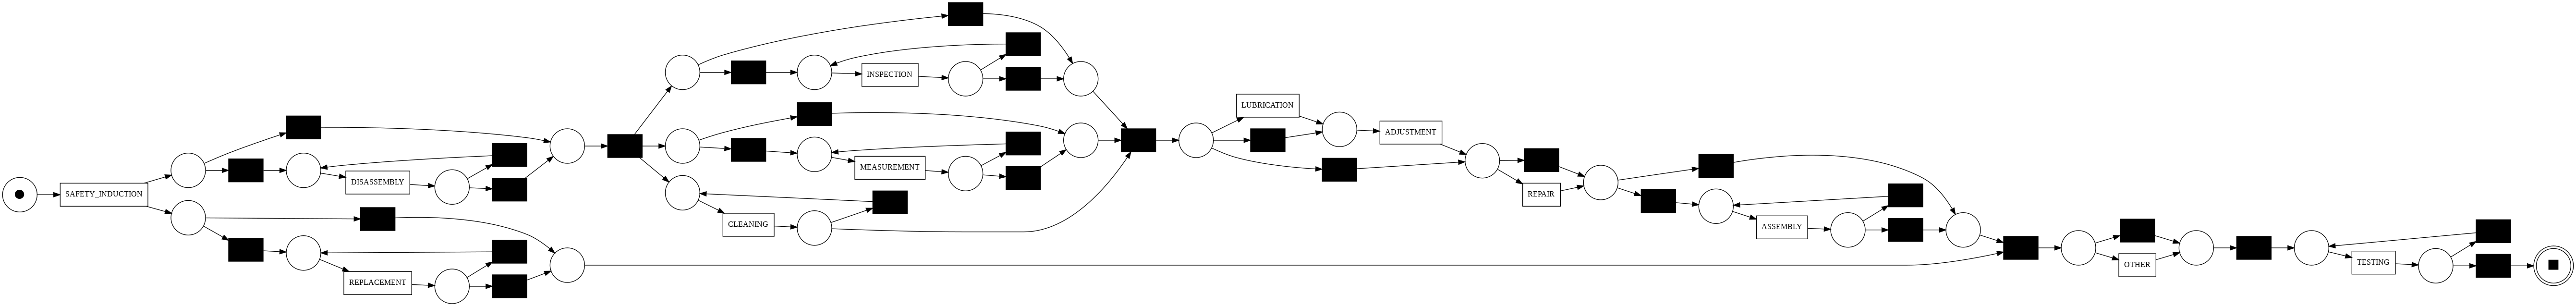

    Figure: /content/drive/MyDrive/pm_project/reports/figures/petri_net_enriched.png
    PNML: /content/drive/MyDrive/pm_project/reports/output/model_enriched.pnml

Results saved: /content/drive/MyDrive/pm_project/reports/output/conformance_results.json

[B] DATASET & MODEL SIZE
  ------------------------------------------------------------------
  Model                Cases  Events    Acts  Variants   Places    Trans
  ------------------------------------------------------------------
  As-Is                   52     255     112        36       81      119
  Enriched AI             52     308      12        30       31       43

[C] CONFORMANCE COMPARISON
  ----------------------------------------------------------------------
  Metric                   As-Is      Enriched       Delta     Direction
  ----------------------------------------------------------------------
  Fitness                 0.9833        0.9606 DOWN  0.0227      decrease
  Precision               0.8716        0.

In [ ]:
print("\n" + "=" * 61)
print("STEP 3 - Process Model Discovery & Conformance Checking")
print("=" * 61)

ENRICHED_CSV = P["log_ai"] if os.path.exists(P["log_ai"]) else P["log_enr"]
ENRICHED_LABEL = "Enriched AI" if os.path.exists(P["log_ai"]) else "Enriched (rule-based)"

_df_check = pd.read_csv(ENRICHED_CSV, nrows=1, encoding="utf-8-sig")
if ENRICHED_ACTIVITY_COL not in _df_check.columns:
    ENRICHED_ACTIVITY_COL = "abstracted_activity"
    print(f"[FALLBACK] action_type not found, using: {ENRICHED_ACTIVITY_COL}")

experiments = [
    PMExperiment(
        label="asis",
        name="As-Is",
        csv_path=P["log_raw"],
        activity_col=ASIS_ACTIVITY_COL,
        noise=NOISE_THRESHOLD,
    ),
    PMExperiment(
        label="enriched",
        name=ENRICHED_LABEL,
        csv_path=ENRICHED_CSV,
        activity_col=ENRICHED_ACTIVITY_COL,
        noise=NOISE_THRESHOLD,
    ),
]

results = {}
models = {}

for idx, exp in enumerate(experiments, start=1):
    print(f"\n[{idx}] {exp.name}")
    print(f"    file         : {os.path.basename(exp.csv_path)}")
    print(f"    concept:name : {exp.activity_col}")
    print(f"    timestamp    : {exp.timestamp_col}")
    print(f"    algorithm    : pm4py.discover_petri_net_inductive noise_threshold={exp.noise}")

    df_log = pm_load_event_dataframe(exp.csv_path, exp.activity_col, exp.timestamp_col, exp.end_timestamp_col)
    log = pm_to_event_log(df_log)

    net, im, fm = pm_discover_petri_net(df_log, noise=exp.noise)
    conf = pm_compute_conformance(log, net, im, fm)
    stats = pm_model_stats(df_log, log, net)

    print(
        f"    cases={stats['cases']}, events={stats['events']}, "
        f"acts={stats['unique_activities']}, variants={stats['trace_variants']}"
    )
    print(
        f"    fitness={conf['fitness']}, precision={conf['precision']}, "
        f"generalization={conf['generalization']}, simplicity={conf['simplicity']}, "
        f"f1={conf['f1_fit_prec']}"
    )

    pm_activity_stats(df_log).to_csv(
        os.path.join(P["out_dir"], f"activity_stats_{exp.label}.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    pm_save_petri_artifacts(net, im, fm, exp.label, show_inline=VIEW_PETRI_NET_INLINE)

    results[exp.label] = conf
    results[f"{exp.label}_stats"] = {
        "file": os.path.basename(exp.csv_path),
        "activity_col": exp.activity_col,
        "timestamp_col": exp.timestamp_col,
        "algorithm": "pm4py.discover_petri_net_inductive",
        "noise": exp.noise,
        **stats,
    }
    models[exp.label] = {
        "df": df_log,
        "log": log,
        "net": net,
        "initial_marking": im,
        "final_marking": fm,
    }

with open(P["conf_json"], "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"\nResults saved: {P['conf_json']}")

print("\n[B] DATASET & MODEL SIZE")
print("  " + "-" * 66)
print(f"  {'Model':<18}{'Cases':>8}{'Events':>8}{'Acts':>8}{'Variants':>10}{'Places':>9}{'Trans':>9}")
print("  " + "-" * 66)
for lbl in ["asis", "enriched"]:
    s = results[f"{lbl}_stats"]
    name = "As-Is" if lbl == "asis" else ENRICHED_LABEL
    print(
        f"  {name:<18}{s['cases']:>8}{s['events']:>8}{s['unique_activities']:>8}"
        f"{s['trace_variants']:>10}{s['places']:>9}{s['transitions']:>9}"
    )

print("\n[C] CONFORMANCE COMPARISON")
print("  " + "-" * 70)
print(f"  {'Metric':<18}{'As-Is':>12}{'Enriched':>14}{'Delta':>12}{'Direction':>14}")
print("  " + "-" * 70)
for key, label in [
    ("fitness", "Fitness"),
    ("precision", "Precision"),
    ("generalization", "Generalization"),
    ("simplicity", "Simplicity"),
    ("f1_fit_prec", "F1(fit*prec)"),
]:
    a = results["asis"][key]
    e = results["enriched"][key]
    d = e - a
    arrow = "UP" if d > 0.005 else ("DOWN" if d < -0.005 else "SAME")
    direction = "stable" if abs(d) <= 0.005 else ("increase" if d > 0 else "decrease")
    print(f"  {label:<18}{a:>12.4f}{e:>14.4f}{arrow:>5} {abs(d):>7.4f}{direction:>14}")

---
## Step 3B — Pandas DataFrame Result Tables

Cell ini menampilkan hasil terakhir dalam bentuk **DataFrame pandas** agar lebih mudah dibaca, dijelaskan ke dosen, dan dibandingkan dengan output teks di Step 3.

Output yang ditampilkan:
- ringkasan ukuran model As-Is vs Enriched AI,
- tabel conformance comparison,
- distribusi `action_type` pada event log Enriched AI,
- contoh hasil annotation/enrichment dari aktivitas mentah ke label AI.



STEP 3B - Pandas DataFrame Result Tables


### [B] Dataset & Model Size

Model,Cases,Events,Activities,Variants,Places,Transitions
As-Is,52,255,112,36,81,119
Enriched AI,52,308,12,30,31,43


### Ringkasan perubahan ukuran model

Metric,As-Is,Enriched AI,Delta,Change (%)
Cases,52,52,+0,+0.00%
Events,255,308,+53,+20.78%
Activities,112,12,-100,-89.29%
Variants,36,30,-6,-16.67%
Places,81,31,-50,-61.73%
Transitions,119,43,-76,-63.87%


### [C] Conformance Comparison

Metric,As-Is,Enriched AI,Delta,Direction
Fitness,0.9833,0.9606,-0.0227,DOWN / decrease
Precision,0.8716,0.5063,-0.3653,DOWN / decrease
Generalization,0.0807,0.6969,+0.6162,UP / increase
Simplicity,0.7246,0.6727,-0.0519,DOWN / decrease
F1 Fitness-Precision,0.9241,0.6631,-0.2610,DOWN / decrease


### Distribusi `action_type` pada Enriched AI

action_type,events,percentage
TESTING,53,17.21%
SAFETY_INDUCTION,52,16.88%
CLEANING,52,16.88%
INSPECTION,51,16.56%
MEASUREMENT,45,14.61%
REPLACEMENT,20,6.49%
DISASSEMBLY,12,3.90%
ADJUSTMENT,9,2.92%
ASSEMBLY,7,2.27%
REPAIR,4,1.30%


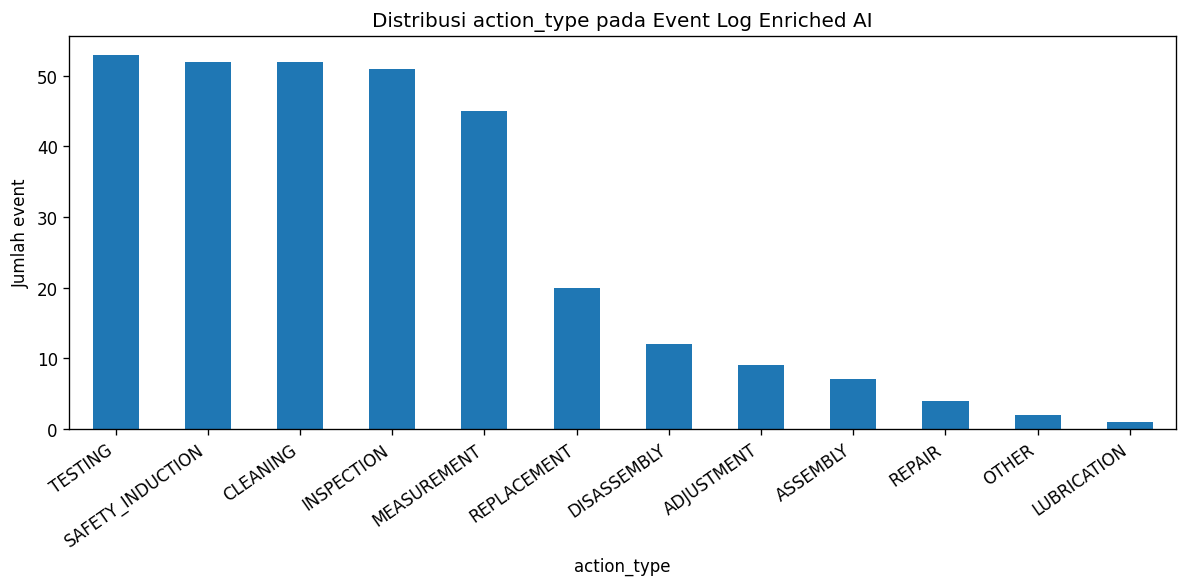

### Contoh hasil enrichment AI

case_id,activity,action_type,component_name,sub_system,wbs_area,confidence,semantic_basis,is_split,split_of
AUTO_001,Safety Induction,SAFETY_INDUCTION,GENERAL,PREPARATION,PREPARATION,1.00,Aktivitas briefing keselamatan kerja sebelum memulai maintenance.,False,nan
AUTO_001,PEMBERSIHAN,CLEANING,GENERAL,GENERAL,GENERAL,0.95,Pembersihan komponen sebagai tahap awal maintenance.,True,PEMBERSIHAN DAN PEMERIKSAAN
AUTO_001,PEMERIKSAAN,INSPECTION,GENERAL,GENERAL,GENERAL,0.95,Pemeriksaan kondisi fisik komponen setelah dibersihkan.,True,PEMBERSIHAN DAN PEMERIKSAAN
AUTO_001,PENGUJIAN / KALIBRASI,MEASUREMENT,GENERAL,CONTROL_INSTRUMENT,CONTROL_INSTRUMENT,0.85,Pengukuran parameter teknis dan penyetelan instrumen kontrol.,False,nan
AUTO_001,Post Maintenace Test,TESTING,GENERAL,COMMISSIONING,COMMISSIONING,1.00,Uji fungsi operasional setelah seluruh rangkaian maintenance selesai.,False,nan
AUTO_002,Safety Induction,SAFETY_INDUCTION,GENERAL,GENERAL,PREPARATION,1.00,Aktivitas persiapan keselamatan kerja sebelum memulai maintenance.,False,nan
AUTO_002,PEMBERSIHAN panel 52G,CLEANING,PANEL 52G,ELECTRICAL_AUXILIARY,ELECTRICAL_LV,0.95,Pembersihan fisik panel listrik untuk menghilangkan debu atau kontaminan.,True,Pembersihan dan Pemeriksaan panel 52G
AUTO_002,PEMERIKSAAN panel 52G,INSPECTION,PANEL 52G,ELECTRICAL_AUXILIARY,ELECTRICAL_LV,0.95,Pemeriksaan visual kondisi komponen internal panel listrik.,True,Pembersihan dan Pemeriksaan panel 52G
AUTO_002,IR Test,MEASUREMENT,PANEL 52G,ELECTRICAL_AUXILIARY,ELECTRICAL_LV,1.00,Pengukuran tahanan isolasi panel listrik untuk memastikan integritas dielektrik.,False,nan
AUTO_002,Pengujian Tahanan Kontak,MEASUREMENT,PANEL 52G,ELECTRICAL_AUXILIARY,ELECTRICAL_LV,1.00,Pengukuran tahanan kontak untuk memverifikasi kualitas koneksi elektrik.,False,nan


### Ringkasan enrichment per `action_type`

action_type,events,example_raw_activity,example_component,example_sub_system,avg_confidence
TESTING,53,Post Maintenace Test,GENERAL,COMMISSIONING,0.96
CLEANING,52,PEMBERSIHAN,GENERAL,GENERAL,0.94
SAFETY_INDUCTION,52,Safety Induction,GENERAL,PREPARATION,1.00
INSPECTION,51,PEMERIKSAAN,GENERAL,GENERAL,0.93
MEASUREMENT,45,PENGUJIAN / KALIBRASI,GENERAL,CONTROL_INSTRUMENT,0.94
REPLACEMENT,20,PENGGANTIAN DAN INTAKE VALVE,INTAKE VALVE,ENGINE_TOP_END,0.95
DISASSEMBLY,12,LEPAS THERMOSTAT,THERMOSTAT,COOLING_SYSTEM,0.97
ADJUSTMENT,9,KALIBRASI RELAY PROTEKSI TRAFO,PROTECTION RELAY,CONTROL_INSTRUMENT,0.86
ASSEMBLY,7,PEMASANGAN THERMOSTAT,THERMOSTAT,COOLING_SYSTEM,0.98
REPAIR,4,LAPPING SEAT VALVE (SKIR VALVE),VALVE SEAT,ENGINE_TOP_END,0.94



DataFrame tables saved to:
 - /content/drive/MyDrive/pm_project/reports/output/table_model_size_summary.csv
 - /content/drive/MyDrive/pm_project/reports/output/table_model_size_delta.csv
 - /content/drive/MyDrive/pm_project/reports/output/table_conformance_summary.csv
 - /content/drive/MyDrive/pm_project/reports/output/table_enriched_action_type_distribution.csv
 - /content/drive/MyDrive/pm_project/reports/output/table_enrichment_sample.csv


In [ ]:
from IPython.display import display, Markdown

print("\n" + "=" * 58)
print("STEP 3B - Pandas DataFrame Result Tables")
print("=" * 58)

# -------------------------------------------------------------------
# 1) Dataset & model size summary
# -------------------------------------------------------------------
df_model_size_summary = pd.DataFrame([
    {
        "Model": "As-Is",
        "Cases": results["asis_stats"]["cases"],
        "Events": results["asis_stats"]["events"],
        "Activities": results["asis_stats"]["unique_activities"],
        "Variants": results["asis_stats"]["trace_variants"],
        "Places": results["asis_stats"]["places"],
        "Transitions": results["asis_stats"]["transitions"],
    },
    {
        "Model": ENRICHED_LABEL,
        "Cases": results["enriched_stats"]["cases"],
        "Events": results["enriched_stats"]["events"],
        "Activities": results["enriched_stats"]["unique_activities"],
        "Variants": results["enriched_stats"]["trace_variants"],
        "Places": results["enriched_stats"]["places"],
        "Transitions": results["enriched_stats"]["transitions"],
    },
])

# Tambahan ringkasan perubahan agar mudah dijelaskan
df_model_size_delta = pd.DataFrame([
    {
        "Metric": col,
        "As-Is": df_model_size_summary.loc[0, col],
        "Enriched AI": df_model_size_summary.loc[1, col],
        "Delta": df_model_size_summary.loc[1, col] - df_model_size_summary.loc[0, col],
        "Change (%)": (
            (df_model_size_summary.loc[1, col] - df_model_size_summary.loc[0, col])
            / df_model_size_summary.loc[0, col] * 100
            if df_model_size_summary.loc[0, col] != 0 else np.nan
        ),
    }
    for col in ["Cases", "Events", "Activities", "Variants", "Places", "Transitions"]
])

display(Markdown("### [B] Dataset & Model Size"))
display(
    df_model_size_summary.style
    .hide(axis="index")
    .format({c: "{:,.0f}" for c in ["Cases", "Events", "Activities", "Variants", "Places", "Transitions"]})
)

display(Markdown("### Ringkasan perubahan ukuran model"))
display(
    df_model_size_delta.style
    .hide(axis="index")
    .format({"As-Is": "{:,.0f}", "Enriched AI": "{:,.0f}", "Delta": "{:+,.0f}", "Change (%)": "{:+.2f}%"})
)

# -------------------------------------------------------------------
# 2) Conformance comparison table
# -------------------------------------------------------------------
def _metric_direction(delta, threshold=0.005):
    if delta > threshold:
        return "UP / increase"
    if delta < -threshold:
        return "DOWN / decrease"
    return "SAME / stable"

metric_specs = [
    ("fitness", "Fitness"),
    ("precision", "Precision"),
    ("generalization", "Generalization"),
    ("simplicity", "Simplicity"),
]

# F1-score ditampilkan jika memang ada pada hasil.
if "f1_fit_prec" in results["asis"] and "f1_fit_prec" in results["enriched"]:
    metric_specs.append(("f1_fit_prec", "F1 Fitness-Precision"))

df_conformance_summary = pd.DataFrame([
    {
        "Metric": label,
        "As-Is": results["asis"][key],
        "Enriched AI": results["enriched"][key],
        "Delta": results["enriched"][key] - results["asis"][key],
        "Direction": _metric_direction(results["enriched"][key] - results["asis"][key]),
    }
    for key, label in metric_specs
])

display(Markdown("### [C] Conformance Comparison"))
display(
    df_conformance_summary.style
    .hide(axis="index")
    .format({"As-Is": "{:.4f}", "Enriched AI": "{:.4f}", "Delta": "{:+.4f}"})
)

# -------------------------------------------------------------------
# 3) Distribusi activity/action_type pada Enriched AI
# -------------------------------------------------------------------
df_activity_distribution = (
    models["enriched"]["df"]["concept:name"]
    .value_counts()
    .rename_axis("action_type")
    .reset_index(name="events")
)
df_activity_distribution["percentage"] = (
    df_activity_distribution["events"] / df_activity_distribution["events"].sum() * 100
)

display(Markdown("### Distribusi `action_type` pada Enriched AI"))
display(
    df_activity_distribution.style
    .hide(axis="index")
    .format({"events": "{:,.0f}", "percentage": "{:.2f}%"})
)

# Visualisasi distribusi action_type.
ax = df_activity_distribution.plot(
    kind="bar",
    x="action_type",
    y="events",
    legend=False,
    figsize=(10, 5)
)
ax.set_title("Distribusi action_type pada Event Log Enriched AI")
ax.set_xlabel("action_type")
ax.set_ylabel("Jumlah event")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4) Contoh hasil enrichment dari raw activity ke annotation AI
# -------------------------------------------------------------------
df_enriched_preview = pd.read_csv(ENRICHED_CSV, encoding="utf-8-sig")

preview_cols = [
    "case_id",
    "activity",
    "action_type",
    "component_name",
    "sub_system",
    "wbs_area",
    "confidence",
    "semantic_basis",
    "is_split",
    "split_of",
]
preview_cols = [col for col in preview_cols if col in df_enriched_preview.columns]

df_enrichment_sample = df_enriched_preview[preview_cols].head(25).copy()

display(Markdown("### Contoh hasil enrichment AI"))
display(
    df_enrichment_sample.style
    .hide(axis="index")
    .format({"confidence": "{:.2f}"})
)

# -------------------------------------------------------------------
# 5) Ringkasan mapping raw activity -> action_type
# -------------------------------------------------------------------
if {"activity", "action_type"}.issubset(df_enriched_preview.columns):
    agg_dict = {
        "events": ("action_type", "size"),
        "example_raw_activity": ("activity", "first"),
    }
    if "component_name" in df_enriched_preview.columns:
        agg_dict["example_component"] = ("component_name", "first")
    if "sub_system" in df_enriched_preview.columns:
        agg_dict["example_sub_system"] = ("sub_system", "first")
    if "confidence" in df_enriched_preview.columns:
        agg_dict["avg_confidence"] = ("confidence", "mean")

    df_action_type_summary = (
        df_enriched_preview
        .groupby("action_type", dropna=False)
        .agg(**agg_dict)
        .reset_index()
        .sort_values("events", ascending=False)
    )

    display(Markdown("### Ringkasan enrichment per `action_type`"))
    display(
        df_action_type_summary.style
        .hide(axis="index")
        .format({"events": "{:,.0f}", "avg_confidence": "{:.2f}"})
    )

# -------------------------------------------------------------------
# 6) Simpan tabel dataframe ke CSV untuk laporan
# -------------------------------------------------------------------
df_model_size_summary.to_csv(os.path.join(P["out_dir"], "table_model_size_summary.csv"), index=False, encoding="utf-8-sig")
df_model_size_delta.to_csv(os.path.join(P["out_dir"], "table_model_size_delta.csv"), index=False, encoding="utf-8-sig")
df_conformance_summary.to_csv(os.path.join(P["out_dir"], "table_conformance_summary.csv"), index=False, encoding="utf-8-sig")
df_activity_distribution.to_csv(os.path.join(P["out_dir"], "table_enriched_action_type_distribution.csv"), index=False, encoding="utf-8-sig")
df_enrichment_sample.to_csv(os.path.join(P["out_dir"], "table_enrichment_sample.csv"), index=False, encoding="utf-8-sig")

print("\nDataFrame tables saved to:")
for fname in [
    "table_model_size_summary.csv",
    "table_model_size_delta.csv",
    "table_conformance_summary.csv",
    "table_enriched_action_type_distribution.csv",
    "table_enrichment_sample.csv",
]:
    print(" -", os.path.join(P["out_dir"], fname))


---
## Step 4 — Report Generation & DFG Analysis

DFG (Directly-Follows Graph), Markdown report, CSV tables.

In [ ]:
print("\n" + "=" * 41)
print("STEP 4 - Report Generation")
print("=" * 41)

s4_enr_act_col = "action_type"
_df_check2 = pd.read_csv(ENRICHED_CSV, nrows=1, encoding="utf-8-sig")
if s4_enr_act_col not in _df_check2.columns:
    s4_enr_act_col = "abstracted_activity"

print(f"  Enriched activity column: {s4_enr_act_col}")

# Reuse model objects dari Step 3 agar tidak ada duplikasi konversi CSV→EventLog.
df_asis = models["asis"]["df"]
df_enr = models["enriched"]["df"]
log_asis = models["asis"]["log"]
log_enr = models["enriched"]["log"]

asis_dfg = pm_discover_dfg_summary(df_asis)
enr_dfg = pm_discover_dfg_summary(df_enr)

pm_save_dfg_image(df_asis, asis_dfg, "asis")
pm_save_dfg_image(df_enr, enr_dfg, "enriched")

for dfg_data, fname in [(asis_dfg, "dfg_asis.csv"), (enr_dfg, "dfg_enriched.csv")]:
    path = os.path.join(P["out_dir"], fname)
    pd.DataFrame(dfg_data["pairs"]).to_csv(path, index=False, encoding="utf-8-sig")
    print(f"    DFG CSV -> {path}")

with open(P["conf_json"], encoding="utf-8") as f:
    conf_data = json.load(f)

conf_path = os.path.join(P["reports_dir"], "conformance_table.csv")
pd.DataFrame([
    {"model": "As-Is (Baseline)", **conf_data["asis"]},
    {"model": ENRICHED_LABEL, **conf_data["enriched"]},
]).to_csv(conf_path, index=False, encoding="utf-8-sig")
print(f"    Conformance CSV -> {conf_path}")

a, e = conf_data["asis"], conf_data["enriched"]
as_s, en_s = conf_data["asis_stats"], conf_data["enriched_stats"]

def chg(av, ev):
    d = ev - av
    return f"{'UP' if d > 0.005 else ('DOWN' if d < -0.005 else 'SAME')} {abs(d):.4f}"

lines = [
    "# Process Mining Report — Maintenance Event Log", "",
    "> Auto-generated by pipeline_full.ipynb", "", "---",
    "## 1. Dataset Overview", "",
    "| | As-Is | Enriched |", "|---|---|---|",
    f"| Unique Activities | **{as_s['unique_activities']}** | **{en_s['unique_activities']}** |",
    f"| Trace Variants | {as_s['trace_variants']} | {en_s['trace_variants']} |",
    f"| Petri Net Places | {as_s['places']} | {en_s['places']} |",
    f"| Petri Net Transitions | {as_s['transitions']} | {en_s['transitions']} |", "",
    "---", "## 2. Conformance Checking (Token-Based Replay)", "",
    "| Metric | As-Is | Enriched | Change |", "|--------|-------|----------|--------|",
    f"| **Fitness** | {a['fitness']:.4f} | {e['fitness']:.4f} | {chg(a['fitness'], e['fitness'])} |",
    f"| **Precision** | {a['precision']:.4f} | {e['precision']:.4f} | {chg(a['precision'], e['precision'])} |",
    f"| Generalization | {a['generalization']:.4f} | {e['generalization']:.4f} | {chg(a['generalization'], e['generalization'])} |",
    f"| Simplicity | {a['simplicity']:.4f} | {e['simplicity']:.4f} | {chg(a['simplicity'], e['simplicity'])} |",
    f"| **F1(fit x prec)** | {a['f1_fit_prec']:.4f} | {e['f1_fit_prec']:.4f} | **{chg(a['f1_fit_prec'], e['f1_fit_prec'])}** |",
    "", "---", "## 3. DFG Top Patterns", "",
    "### As-Is Top 8", "", "| From | To | Freq | Avg Duration |", "|------|----|------|--------------|",
]
for p in asis_dfg["pairs"][:8]:
    lines.append(f"| {p['from'][:40]} | {p['to'][:40]} | {p['frequency']} | {p['avg_duration_h']} h |")

lines += ["", "### Enriched Top 8", "", "| From | To | Freq | Avg Duration |", "|------|----|------|--------------|"]
for p in enr_dfg["pairs"][:8]:
    lines.append(f"| {p['from']} | {p['to']} | {p['frequency']} | {p['avg_duration_h']} h |")

lines += ["", "---", "*Generated by pipeline_full.ipynb*"]

report_path = os.path.join(P["reports_dir"], "pm_report.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"    Report -> {report_path}")

print("\n  Top 6 Enriched DFG pairs:")
for p in enr_dfg["pairs"][:6]:
    print(f"    {p['from']:<22} -> {p['to']:<22}  freq={p['frequency']}  avg={p['avg_duration_h']}h")


STEP 4 - Report Generation
  Enriched activity column: action_type
    DFG figure -> /content/drive/MyDrive/pm_project/reports/figures/dfg_asis.png
    DFG figure -> /content/drive/MyDrive/pm_project/reports/figures/dfg_enriched.png
    DFG CSV -> /content/drive/MyDrive/pm_project/reports/output/dfg_asis.csv
    DFG CSV -> /content/drive/MyDrive/pm_project/reports/output/dfg_enriched.csv
    Conformance CSV -> /content/drive/MyDrive/pm_project/reports/conformance_table.csv
    Report -> /content/drive/MyDrive/pm_project/reports/pm_report.md

  Top 6 Enriched DFG pairs:
    CLEANING               -> INSPECTION              freq=21  avg=6.25h
    MEASUREMENT            -> CLEANING                freq=19  avg=13.44h
    SAFETY_INDUCTION       -> MEASUREMENT             freq=18  avg=7.04h
    INSPECTION             -> TESTING                 freq=15  avg=0.5h
    SAFETY_INDUCTION       -> CLEANING                freq=14  avg=9.8h
    SAFETY_INDUCTION       -> INSPECTION              freq=

---
## Visualisasi

Radar chart, bar chart, DFG heatmap, case timeline, trace variants, dan dashboard.

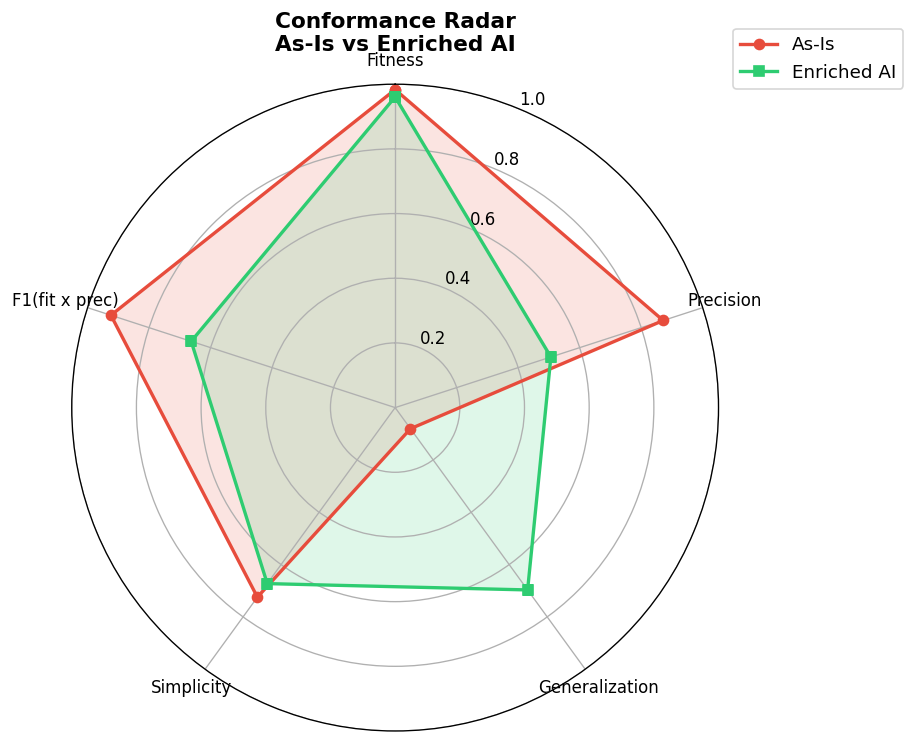

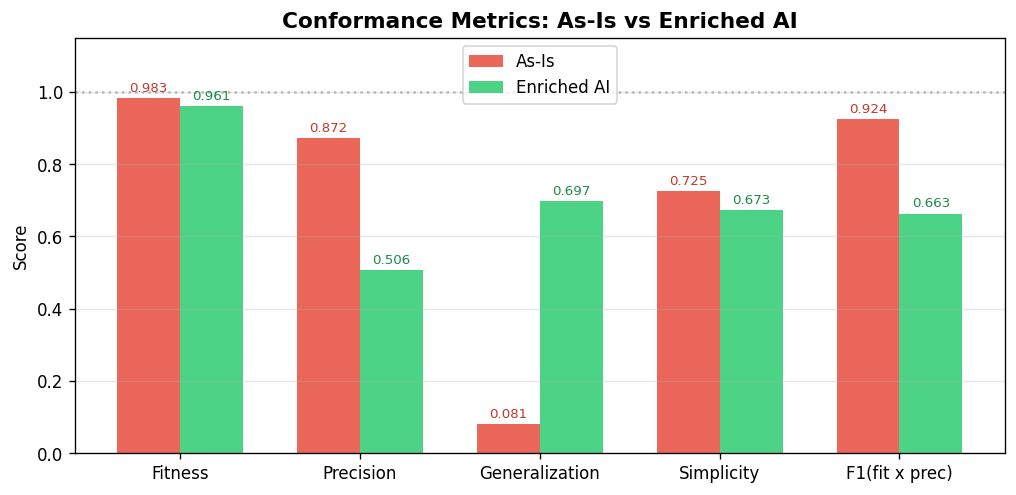

In [ ]:
def _get(d, *keys):
    for k in keys:
        if k in d:
            return d[k]
    return 0

metrics = ['fitness', 'precision', 'generalization', 'simplicity', 'f1_fit_prec']
labels  = ['Fitness', 'Precision', 'Generalization', 'Simplicity', 'F1(fit x prec)']
vals_asis = [_get(results['asis'], m) for m in metrics]
vals_enr  = [_get(results['enriched'], m) for m in metrics]

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
vals_asis_r = vals_asis + [vals_asis[0]]
vals_enr_r  = vals_enr + [vals_enr[0]]
angles_r    = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles), labels, fontsize=10)
ax.plot(angles_r, vals_asis_r, 'o-', linewidth=2, color='#E74C3C', label='As-Is')
ax.fill(angles_r, vals_asis_r, alpha=0.15, color='#E74C3C')
ax.plot(angles_r, vals_enr_r, 's-', linewidth=2, color='#2ECC71', label=ENRICHED_LABEL)
ax.fill(angles_r, vals_enr_r, alpha=0.15, color='#2ECC71')
ax.set_ylim(0, 1); ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title(f'Conformance Radar\nAs-Is vs {ENRICHED_LABEL}', fontsize=13, fontweight='bold', pad=20)
plt.savefig(os.path.join(P['fig_dir'], 'conformance_radar.png'), bbox_inches='tight', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(metrics)); w = 0.35
bars1 = ax.bar(x - w / 2, vals_asis, w, label='As-Is', color='#E74C3C', alpha=0.85)
bars2 = ax.bar(x + w / 2, vals_enr, w, label=ENRICHED_LABEL, color='#2ECC71', alpha=0.85)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#C0392B')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#1A8A4A')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'Conformance Metrics: As-Is vs {ENRICHED_LABEL}', fontweight='bold', fontsize=13)
ax.legend(); ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5); ax.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(P['fig_dir'], 'conformance_bar.png'), bbox_inches='tight', dpi=150)
plt.show()

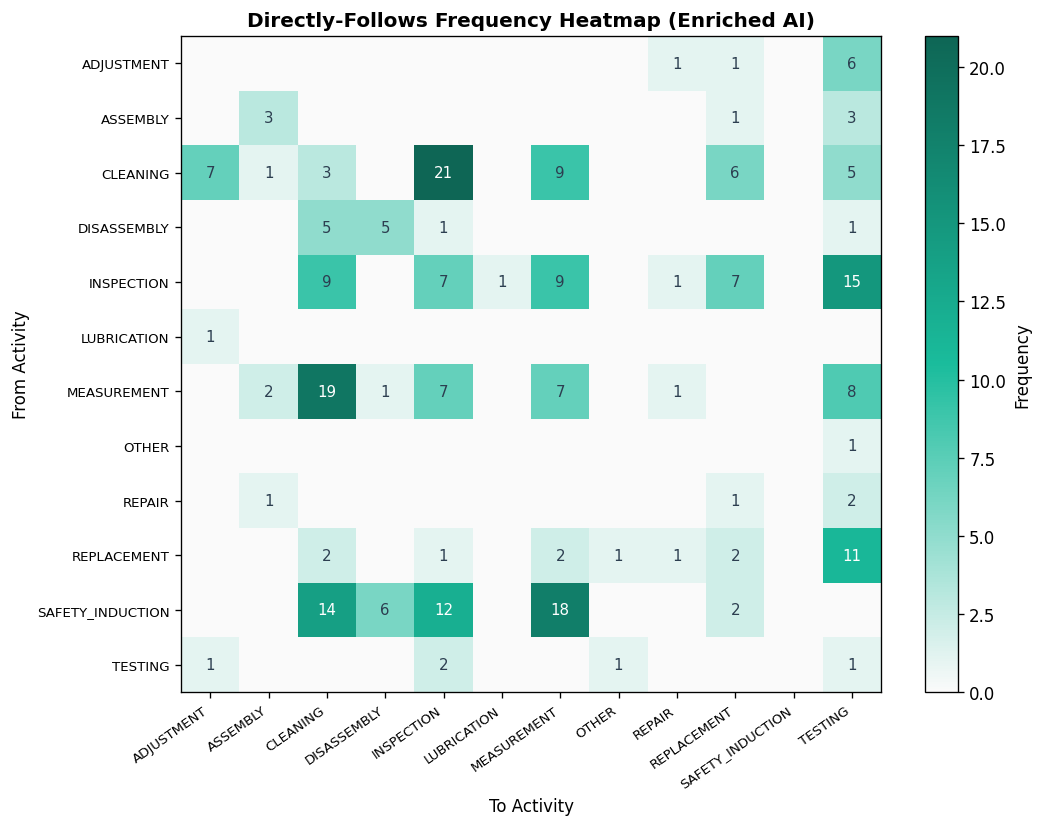

In [ ]:
dfg_enr_freq, _, _ = pm4py.discover_dfg(models['enriched']['log'])
acts = sorted(set(a for (a, b) in dfg_enr_freq) | set(b for (a, b) in dfg_enr_freq))
matrix = pd.DataFrame(0, index=acts, columns=acts)
for (src, tgt), freq in dfg_enr_freq.items():
    matrix.loc[src, tgt] = freq

cmap = LinearSegmentedColormap.from_list('pm', ['#FAFAFA', '#1ABC9C', '#0E6655'])
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matrix.values, cmap=cmap, aspect='auto')
ax.set_xticks(range(len(acts))); ax.set_yticks(range(len(acts)))
ax.set_xticklabels(acts, rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(acts, fontsize=8)
ax.set_xlabel('To Activity', fontsize=10); ax.set_ylabel('From Activity', fontsize=10)
ax.set_title(f'Directly-Follows Frequency Heatmap ({ENRICHED_LABEL})', fontweight='bold', fontsize=12)
for i in range(len(acts)):
    for j in range(len(acts)):
        val = matrix.iloc[i, j]
        if val > 0:
            ax.text(j, i, str(int(val)), ha='center', va='center',
                    fontsize=9, color='white' if val > matrix.values.max() * 0.5 else '#2C3E50')
plt.colorbar(im, ax=ax, label='Frequency')
plt.tight_layout()
plt.savefig(os.path.join(P['fig_dir'], 'dfg_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()

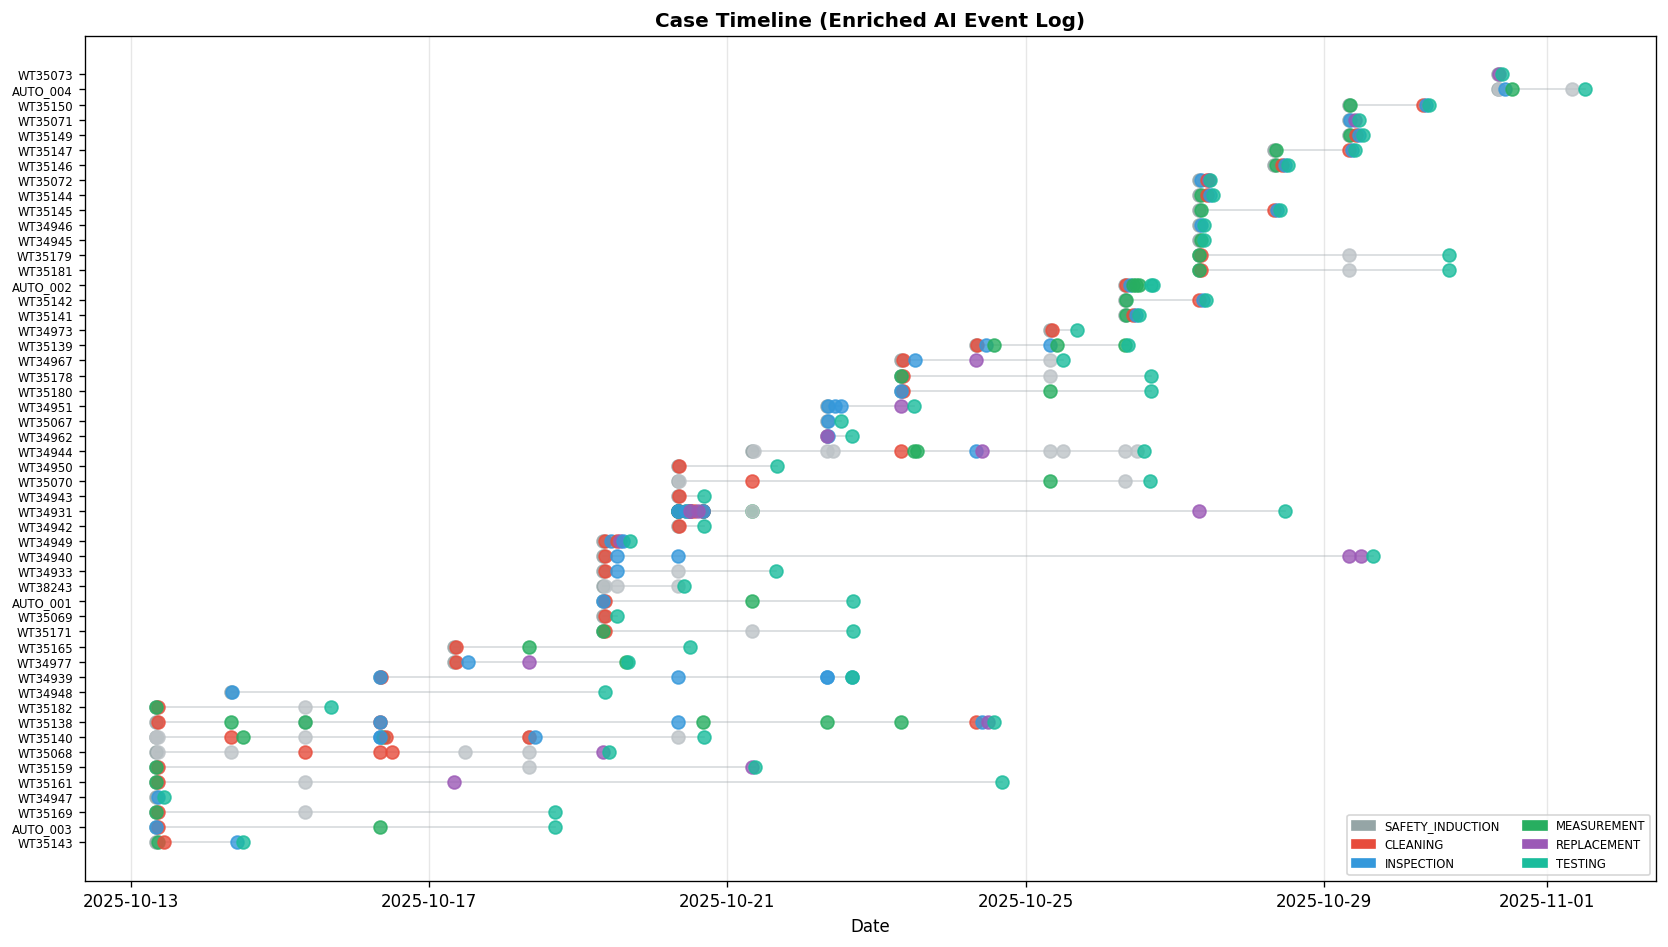

In [ ]:
df_enr = pd.read_csv(ENRICHED_CSV, encoding='utf-8-sig')
ts_col_plot = 'timestamp' if 'timestamp' in df_enr.columns else 'timestamp_end'
df_enr[ts_col_plot] = pd.to_datetime(df_enr[ts_col_plot], errors='coerce')
df_enr = df_enr.dropna(subset=[ts_col_plot])

case_timeline = df_enr.groupby('case_id')[ts_col_plot].agg(['min', 'max'])
case_timeline['duration_days'] = (case_timeline['max'] - case_timeline['min']).dt.total_seconds() / 86400
case_timeline = case_timeline.sort_values('min')

CAT_COLORS = {
    'SAFETY_INDUCTION': '#95A5A6', 'CLEANING': '#E74C3C', 'INSPECTION': '#3498DB',
    'MEASUREMENT': '#27AE60', 'REPLACEMENT': '#9B59B6', 'TESTING': '#1ABC9C',
    'OTHER': '#BDC3C7',
}

fig, ax = plt.subplots(figsize=(14, 8))
cases_list = list(case_timeline.index)
for i, case_id in enumerate(cases_list):
    case_events = df_enr[df_enr['case_id'] == case_id]
    for _, row in case_events.iterrows():
        cat = row.get(ENRICHED_ACTIVITY_COL, 'OTHER')
        color = CAT_COLORS.get(cat, '#BDC3C7')
        ax.scatter(row[ts_col_plot], i, c=color, s=60, zorder=3, alpha=0.8)
    row_start, row_end = case_timeline.loc[case_id, 'min'], case_timeline.loc[case_id, 'max']
    ax.plot([row_start, row_end], [i, i], color='#BDC3C7', linewidth=1, zorder=1, alpha=0.6)

ax.set_yticks(range(len(cases_list))); ax.set_yticklabels(cases_list, fontsize=7)
ax.set_xlabel('Date', fontsize=10)
ax.set_title(f'Case Timeline ({ENRICHED_LABEL} Event Log)', fontweight='bold', fontsize=12)
patches = [mpatches.Patch(color=c, label=k) for k, c in CAT_COLORS.items() if k != 'OTHER']
ax.legend(handles=patches, loc='lower right', fontsize=7, ncol=2)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(P['fig_dir'], 'case_timeline.png'), bbox_inches='tight', dpi=150)
plt.show()

As-Is trace variants          : 36
Enriched AI trace variants : 30


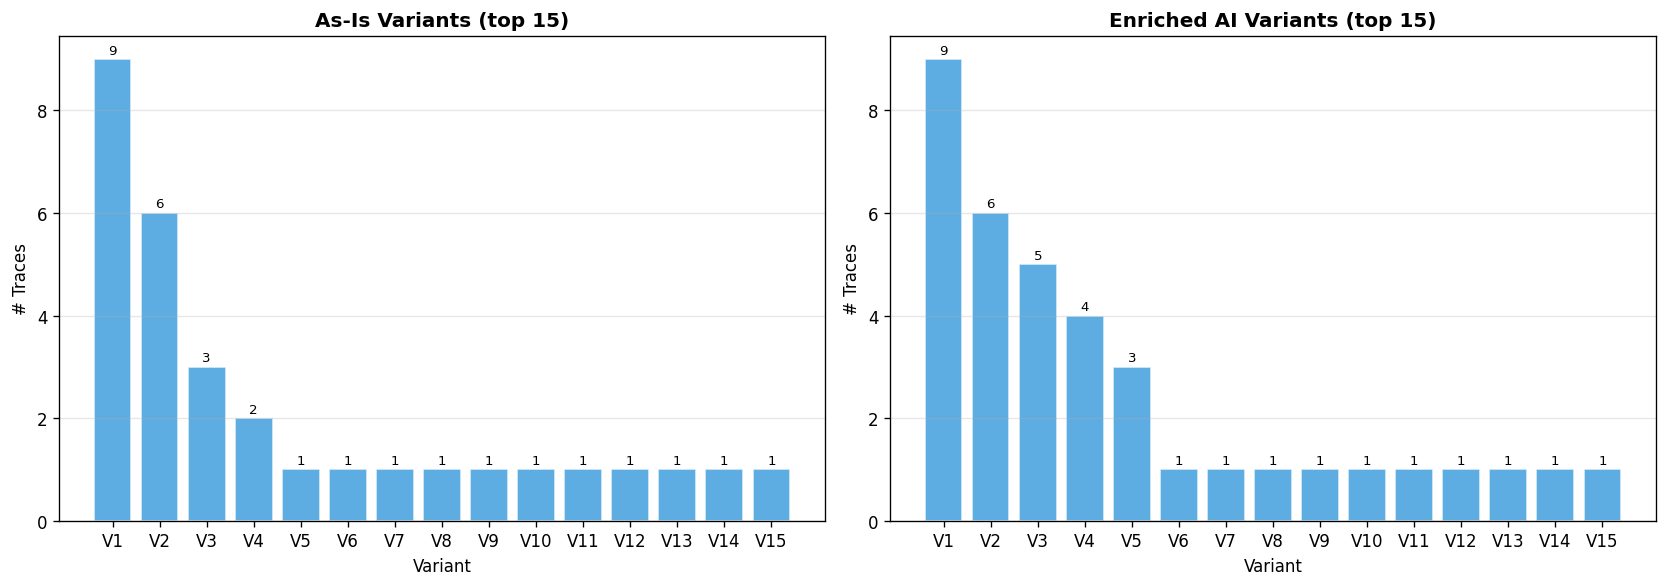

In [ ]:
variants_asis = pm4py.get_variants_as_tuples(models["asis"]["log"])
variants_enr = pm4py.get_variants_as_tuples(models["enriched"]["log"])

print(f"As-Is trace variants          : {len(variants_asis)}")
print(f"{ENRICHED_LABEL} trace variants : {len(variants_enr)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_plt, variants, title in [
    (axes[0], variants_asis, "As-Is Variants (top 15)"),
    (axes[1], variants_enr, f"{ENRICHED_LABEL} Variants (top 15)"),
]:
    sorted_v = sorted(variants.items(), key=lambda x: -len(x[1]))[:15]
    vlabels = [f"V{i + 1}" for i in range(len(sorted_v))]
    counts = [len(traces) for _, traces in sorted_v]
    bars = ax_plt.bar(vlabels, counts, color="#3498DB", alpha=0.8, edgecolor="white")
    ax_plt.set_xlabel("Variant")
    ax_plt.set_ylabel("# Traces")
    ax_plt.set_title(title, fontweight="bold")
    ax_plt.grid(axis="y", alpha=0.3)
    for bar, c in zip(bars, counts):
        ax_plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            str(c),
            ha="center",
            va="bottom",
            fontsize=8,
        )
plt.tight_layout()
plt.savefig(os.path.join(P["fig_dir"], "trace_variants.png"), bbox_inches="tight", dpi=150)
plt.show()

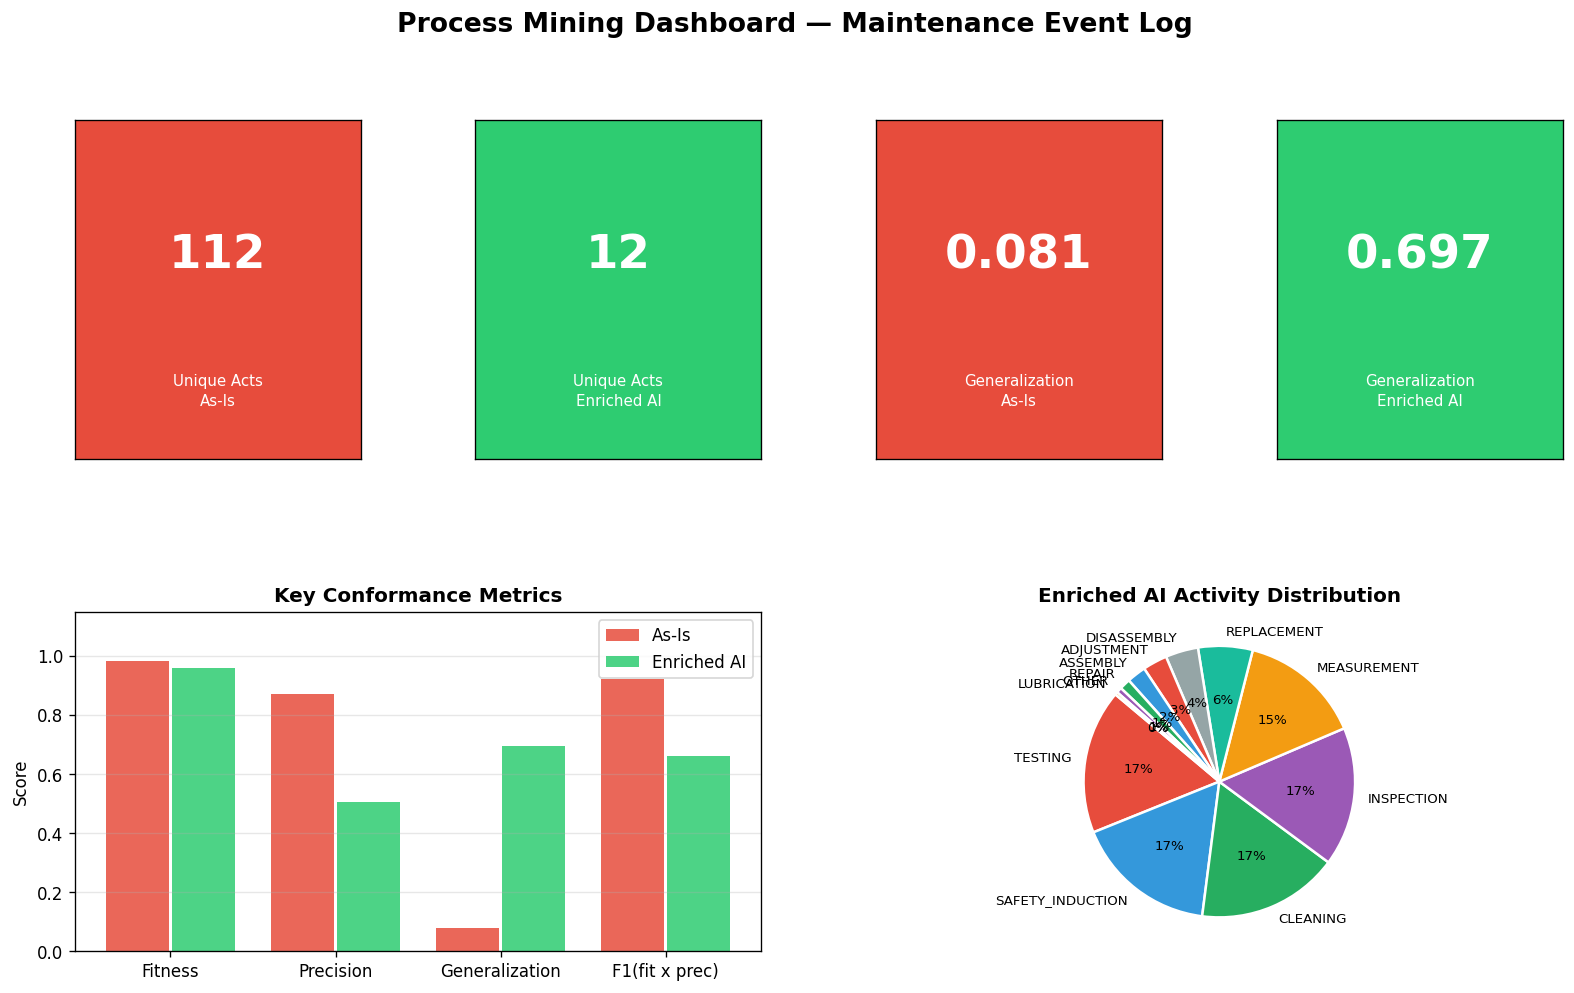

Dashboard analysis complete.


In [ ]:
n_acts_raw = results['asis_stats']['unique_activities']
n_acts_enr = results['enriched_stats']['unique_activities']

fig = plt.figure(figsize=(16, 9))
fig.suptitle('Process Mining Dashboard — Maintenance Event Log', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

kpis = [
    ('Unique Acts\nAs-Is', str(n_acts_raw), '#E74C3C'),
    ('Unique Acts\n' + ENRICHED_LABEL, str(n_acts_enr), '#2ECC71'),
    ('Generalization\nAs-Is', f"{_get(results['asis'], 'generalization'):.3f}", '#E74C3C'),
    ('Generalization\n' + ENRICHED_LABEL, f"{_get(results['enriched'], 'generalization'):.3f}", '#2ECC71'),
]
for i, (label, val, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.6, val, ha='center', va='center', fontsize=28, fontweight='bold',
                color='white', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.2, label, ha='center', va='center', fontsize=9,
                color='white', transform=ax_kpi.transAxes, linespacing=1.4)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])

ax2 = fig.add_subplot(gs[1, :2])
metric_keys = ['fitness', 'precision', 'generalization', 'f1_fit_prec']
metric_labels = ['Fitness', 'Precision', 'Generalization', 'F1(fit x prec)']
asis_vals = [_get(results['asis'], k) for k in metric_keys]
enr_vals = [_get(results['enriched'], k) for k in metric_keys]
x = np.arange(len(metric_keys))
ax2.bar(x - 0.2, asis_vals, 0.38, label='As-Is', color='#E74C3C', alpha=0.85)
ax2.bar(x + 0.2, enr_vals, 0.38, label=ENRICHED_LABEL, color='#2ECC71', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(metric_labels); ax2.set_ylim(0, 1.15); ax2.set_ylabel('Score')
ax2.set_title('Key Conformance Metrics', fontweight='bold'); ax2.legend(); ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 2:])
cat_counts = df_enr[ENRICHED_ACTIVITY_COL].value_counts()
colors_pie = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12', '#1ABC9C', '#95A5A6']
ax3.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.0f%%',
        colors=colors_pie[:len(cat_counts)],
        startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 8})
ax3.set_title(f'{ENRICHED_LABEL} Activity Distribution', fontweight='bold')

plt.savefig(os.path.join(P['fig_dir'], 'dashboard.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard analysis complete.')

In [ ]:
print(f"\n{'='*60}")
print("  Pipeline selesai!")
print(f"\n  Output files:")
for key, path in [
    ('As-Is log',        P['log_raw']),
    ('Enriched log',     P['log_enr']),
    ('AI annotated log', P['log_ai']),
    ('Petri Net As-Is',  os.path.join(P['out_dir'],'model_asis.pnml')),
    ('Petri Net Enrich', os.path.join(P['out_dir'],'model_enriched.pnml')),
    ('Conformance JSON', P['conf_json']),
    ('Markdown Report',  os.path.join(P['reports_dir'],'pm_report.md')),
    ('DFG As-Is CSV',    os.path.join(P['out_dir'],'dfg_asis.csv')),
    ('DFG Enriched CSV', os.path.join(P['out_dir'],'dfg_enriched.csv')),
    ('Radar Chart',      os.path.join(P['fig_dir'],'conformance_radar.png')),
    ('Bar Chart',        os.path.join(P['fig_dir'],'conformance_bar.png')),
    ('DFG Heatmap',      os.path.join(P['fig_dir'],'dfg_heatmap.png')),
    ('Case Timeline',    os.path.join(P['fig_dir'],'case_timeline.png')),
    ('Dashboard',        os.path.join(P['fig_dir'],'dashboard.png')),
]:
    exists = '[OK]' if os.path.exists(path) else '[X]'
    print(f"    {exists} {key:<22} {os.path.relpath(path, BASE)}")
print(f"{'='*60}")


  Pipeline selesai!

  Output files:
    [OK] As-Is log              data/processed/log_raw.csv
    [OK] Enriched log           data/processed/log_enriched.csv
    [OK] AI annotated log       data/processed/log_enriched_ai.csv
    [OK] Petri Net As-Is        reports/output/model_asis.pnml
    [OK] Petri Net Enrich       reports/output/model_enriched.pnml
    [OK] Conformance JSON       reports/output/conformance_results.json
    [OK] Markdown Report        reports/pm_report.md
    [OK] DFG As-Is CSV          reports/output/dfg_asis.csv
    [OK] DFG Enriched CSV       reports/output/dfg_enriched.csv
    [OK] Radar Chart            reports/figures/conformance_radar.png
    [OK] Bar Chart              reports/figures/conformance_bar.png
    [OK] DFG Heatmap            reports/figures/dfg_heatmap.png
    [OK] Case Timeline          reports/figures/case_timeline.png
    [OK] Dashboard              reports/figures/dashboard.png
